# Reproducing the literature triage of the unfiltered MoDPA PTM association list

This notebook reproduces every number, table and stated result in
`20260911-modpa-literature-triage-report.md`. It is written for reviewers of the MoDPA manuscript,
and it is intended to be run top to bottom without editing.

The notebook does not re-implement the analysis. It runs the same scripts, in the same order, that
produced the report (`scripts/s02a_to_parquet.py` through `scripts/s24_monotonicity.py`), then loads
the resulting tables from `work/` and renders each section of the report from them. Section 11
compares every headline figure against the value published in the report and reports a pass or a
fail for each one.

## What the analysis does

The MoDPA network is built from correlations between per-site PTM detection profiles. The question
addressed here is whether the resulting associations correspond to relationships that are already
documented in UniProtKB Swiss-Prot. Each of the 29,211,546 candidate PTM event pairs is assigned an
evidence tier from UniProt annotation alone, before any score is consulted, and the support rate is
then compared against a matched permutation null across strata of the absolute signed distance
correlation (SDC).

Three properties of the analysis determine how the output should be read.

1. **No filtering beyond q < 0.05.** The co-quantification flag is computed, carried and reported,
   but is never used to remove a pair. Sensitivity columns show what each figure would become if
   those pairs were dropped.
2. **Tiers are assigned before any score is read.** The tier logic touches no score column, so the
   classification cannot be influenced by the quantity being tested.
3. **No network access is used by the analysis.** Every PubMed identifier in the outputs comes
   verbatim from a UniProt evidence string or `RX` line in `uniprot_2026_03_sprot.dat.gz`. No web or
   PubMed tool was consulted. The only network request this notebook can make is the one-off
   download of that Swiss-Prot release in section 0.3, and only when a local copy is absent.

## Requirements

**Input files.** Four are study data and must sit in the same directory as this notebook:

| File | Size | Role |
|---|---:|---|
| `20260911-1042-keen_raman-signed-distances.csv.gz` | 1.35 GB | the raw association list, 29,211,546 pairs |
| `20260911-True-data-filtered-distances.csv` | 2.8 MB | the SDC >= 0.6 network, 14,591 edges |
| `20260911-True-data-Leiden-clusters.csv` | 7.5 MB | the weighted Leiden partition, 6,491 nodes |
| `N-runs-per-ptm.csv.gz` | 12 MB | detection frequency per PTM event |

The fifth, `uniprot_2026_03_sprot.dat.gz` (668 MB), is a public archived UniProt release. It does not
have to be circulated with the study data: section 0.3 uses a local copy if there is one and
otherwise downloads release 2026_03 and verifies it. That download happens once.

`20260911-True-data-edges-w-clusters.csv`, which carried the unweighted Leiden partition, has been
withdrawn from the folder. No result in the report used it. The three scripts that read it
(`s01`, `s01b`, `s22`) are therefore not part of this notebook; see section 1.0 of the report.

**Software.** Python 3.11, with `polars`, `pandas`, `duckdb`, `numpy`, `scipy`, `matplotlib` and
`pyarrow`. The exact versions used for the published report are checked below, and a mismatch is
reported as a warning rather than an error.

**Disk.** About 5 GB of intermediate and delivered files are written into `work/` and the project
root. Nothing outside those two locations is touched.

**Memory.** The scripts request `PRAGMA memory_limit='24GB'` from duckdb. On a machine with less
physical memory duckdb spills to its temporary directory instead of failing, so the run still
completes, more slowly. Nothing is loaded into memory whole: the association list is converted to
Parquet once and then queried, and Swiss-Prot is streamed entry by entry.

**Runtime.** About 17 minutes from an empty `work/` on the reference machine. Measured on a cold
start: the matched permutation null 520 s, writing the 1.5 GB delivered TSV 218 s, the Swiss-Prot
parse 98 s, the shortlist 72 s, the tier assignment 26 s, everything else under 20 s each. Note that
the timing column in `scripts/README.md` understates the permutation null, which is the dominant
cost. A second run skips completed steps and takes under a minute.

---

## 0. Configuration

In [1]:
import os, sys, json, time, subprocess, pathlib, textwrap, datetime

# ---- flags a reviewer may want to change -------------------------------------------------------
FORCE_RERUN    = False   # True re-runs every step even when its outputs already exist
RUN_OPTIONAL   = True    # False skips s07 and s19; see the step table in section 1
DUCKDB_THREADS = min(12, os.cpu_count() or 4)   # threads for the notebook's own queries
DUCKDB_MEMORY  = "8GB"                          # memory limit for the notebook's own queries
# ------------------------------------------------------------------------------------------------

# Locate the project root by walking up until scripts/_common.py is found, so the notebook works
# whether it is opened from the project root or from a subdirectory.
here = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [here, *here.parents] if (p / "scripts" / "_common.py").exists()), None)
if PROJECT_ROOT is None:
    raise SystemExit("scripts/_common.py not found. Open this notebook from the project root.")
os.chdir(PROJECT_ROOT)                 # the analysis scripts use sys.path.insert(0, "scripts")
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from _common import BASE, WORK, DATE, RAW, CLUSTERS, EDGES, FILTERED, NRUNS, SPROT, UNIMOD

import duckdb, pandas as pd, numpy as np, polars as pl
import matplotlib as mpl, matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)

LOGDIR = WORK / "nb_logs";    LOGDIR.mkdir(parents=True, exist_ok=True)
FIGDIR = WORK / "nb_figures"; FIGDIR.mkdir(parents=True, exist_ok=True)


def fmt_table(df, fmt=None):
    """Return a display copy of df with the named columns rendered as strings.

    Deliberately avoids the pandas Styler, which requires jinja2. jinja2 is not part of the
    reference environment, and a reviewer should not have to install anything beyond the seven
    packages listed in section 0.1 to read these tables.
    """
    out = df.copy()
    for col, spec in (fmt or {}).items():
        if col in out.columns:
            out[col] = [spec.format(v) if pd.notna(v) else "" for v in out[col]]
    return out

con = duckdb.connect()
con.execute(f"PRAGMA threads={DUCKDB_THREADS}; PRAGMA memory_limit='{DUCKDB_MEMORY}';")
PT = (WORK / "pairs_tiered.parquet").as_posix()   # the central table, written by s13

TIER_LABEL = {1: "1 explicit crosstalk", 2: "2 shared regulator", 3: "3 same protein",
              4: "4 complex or interaction", 5: "5 both sites annotated", 9: "unsupported"}
STRATUM_LABEL = {"S01_<0.25": "S01 <0.25", "S02_0.25-0.30": "S02 0.25-0.30",
                 "S03_0.30-0.35": "S03 0.30-0.35", "S04_0.35-0.40": "S04 0.35-0.40",
                 "S05_0.40-0.45": "S05 0.40-0.45", "S06_0.45-0.50": "S06 0.45-0.50",
                 "S07_0.50-0.55": "S07 0.50-0.55", "S08_0.55-0.60": "S08 0.55-0.60",
                 "S09_0.60-0.70": "S09 0.60-0.70", "S10_0.70+": "S10 >=0.70"}

print(f"project root : {PROJECT_ROOT}")
print(f"work/        : {WORK}")
print(f"duckdb       : {DUCKDB_THREADS} threads, {DUCKDB_MEMORY} limit (notebook queries only)")
print(f"run started  : {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")

project root : D:\MoDPAv1.0-main\let-Claude-cook
work/        : D:\MoDPAv1.0-main\let-Claude-cook\work
duckdb       : 12 threads, 8GB limit (notebook queries only)
run started  : 2026-09-15 16:03:02


### 0.1 Environment

The report was produced with the versions in the `reference` column. A mismatch does not necessarily
change any result, but it is recorded here so that any difference found later can be traced.

In [2]:
REFERENCE_ENV = {"python": "3.11.4", "polars": "1.44.2", "pandas": "3.0.3", "duckdb": "1.5.5",
                 "numpy": "2.4.6", "scipy": "1.17.1", "matplotlib": "3.10.8"}

import scipy
found = {"python": ".".join(map(str, sys.version_info[:3])), "polars": pl.__version__,
         "pandas": pd.__version__, "duckdb": duckdb.__version__, "numpy": np.__version__,
         "scipy": scipy.__version__, "matplotlib": mpl.__version__}

env = pd.DataFrame({"reference": pd.Series(REFERENCE_ENV), "found": pd.Series(found)})
env["match"] = np.where(env.reference == env.found, "same", "DIFFERENT")
display(env)

if (env.match == "DIFFERENT").any():
    print("\nNote: at least one version differs from the reference environment.")
    print("The random seed (42) is fixed in s15 and s24, so the permutation results are")
    print("deterministic within a given numpy version. Small differences in the last decimal of a")
    print("permutation p-value across numpy releases are expected and do not affect any conclusion;")
    print("section 11 checks every headline figure with an explicit tolerance.")
else:
    print("\nEnvironment matches the reference environment exactly.")

,reference,found,match
python,3.11.4,3.11.4,same
polars,1.44.2,1.44.2,same
pandas,3.0.3,3.0.3,same
duckdb,1.5.5,1.5.5,same
numpy,2.4.6,2.4.6,same
scipy,1.17.1,1.17.1,same
matplotlib,3.10.8,3.10.8,same



Environment matches the reference environment exactly.


### 0.2 Input files

Four of the five inputs are the study's own data and must be supplied alongside this notebook. The
fifth, Swiss-Prot release 2026_03, is a public archived release and section 0.3 fetches it if it is
absent, so it does not have to be shared.

The run stops here if one of the four study files is missing. The withdrawn unweighted-partition
file is listed for completeness and is expected to be absent.

In [3]:
STUDY_INPUTS = [(RAW, "raw association list, 29,211,546 pairs"),
                (FILTERED, "SDC >= 0.6 network, 14,591 edges"),
                (CLUSTERS, "weighted Leiden partition, 6,491 nodes"),
                (NRUNS, "detection frequency per PTM event")]
PUBLIC_INPUTS = [(SPROT, "Swiss-Prot release 2026_03; fetched by section 0.3 if absent")]
WITHDRAWN = [(EDGES, "unweighted Leiden partition; withdrawn, not used by any result")]

study_paths = {p for p, _ in STUDY_INPUTS}
rows = []
for p, role in STUDY_INPUTS + PUBLIC_INPUTS + WITHDRAWN:
    ok = p.exists()
    rows.append({"file": p.name,
                 "class": "study data" if p in study_paths else
                          ("public release" if p == SPROT else "withdrawn"),
                 "present": ok,
                 "size_MB": round(p.stat().st_size / 1e6, 1) if ok else None, "role": role})
inv = pd.DataFrame(rows)
display(inv)

missing = [p.name for p, _ in STUDY_INPUTS if not p.exists()]
if missing:
    raise FileNotFoundError("missing study input files, which cannot be downloaded:\n  "
                            + "\n  ".join(missing))
print("All four study input files are present.")

,file,class,present,size_MB,role
0,20260911-1042-keen_raman-signed-distances.csv.gz,study data,True,1349.6,"raw association list, 29,211,546 pairs"
1,20260911-True-data-filtered-distances.csv,study data,True,2.8,"SDC >= 0.6 network, 14,591 edges"
2,20260911-True-data-Leiden-clusters.csv,study data,True,7.5,"weighted Leiden partition, 6,491 nodes"
3,N-runs-per-ptm.csv.gz,study data,True,12.0,detection frequency per PTM event
4,uniprot_2026_03_sprot.dat.gz,public release,True,700.3,Swiss-Prot release 2026_03; fetched by section...
5,20260911-True-data-edges-w-clusters.csv,withdrawn,False,NaN,"unweighted Leiden partition; withdrawn, not us..."


All four study input files are present.


### 0.3 Swiss-Prot release 2026_03

`uniprot_2026_03_sprot.dat.gz` is 668 MB, which makes it awkward to circulate, and it is a public
archived UniProt release rather than study data. This section uses the local copy if there is one
and otherwise downloads it from the UniProt archive or one of its mirrors.

**The release matters.** Tier assignment is site-level matching against this specific release. A
different release shifts the annotation and therefore the tier counts, so the notebook verifies what
it has rather than trusting a filename:

1. SHA-256 against the digest of the file the report was produced from. A match settles it.
2. If the digest differs, which happens when an archive repackages the same content at a different
   gzip compression level, the file is streamed once and checked against the content fingerprint the
   analysis depends on: 575,748 entries in total and 20,431 of them human (report section 5).

Anything else is refused. The notebook will not silently run against the wrong release, and the
current UniProt release is not an acceptable substitute.

If every URL fails, which is what a change to the UniProt archive layout would look like, the cell
prints manual download instructions and stops.

In [4]:
import hashlib, gzip, shutil, tarfile, urllib.request, urllib.error

# Fingerprint of the file the published report was produced from.
SPROT_SHA256  = "c87208822a56e8ae0d6bf5072c287b35e42a8b9f25e8bd771389abc5b7a29c38"
SPROT_BYTES   = 700_301_138
SPROT_ENTRIES = 575_748   # total entries in the release, report section 5
SPROT_HUMAN   = 20_431    # of which human, report section 5

DOWNLOAD_SPROT_IF_MISSING = True    # set False to refuse network access and require a local copy

# The documented UniProt previous-release layout, then two mirrors. The archive packages a release
# as a tar containing uniprot_sprot.dat.gz, which is handled below.
SPROT_URLS = [
  "https://ftp.uniprot.org/pub/databases/uniprot/previous_releases/release-2026_03/knowledgebase/uniprot_sprot-only2026_03.tar.gz",
  "https://ftp.ebi.ac.uk/pub/databases/uniprot/previous_releases/release-2026_03/knowledgebase/uniprot_sprot-only2026_03.tar.gz",
  "https://ftp.expasy.org/databases/uniprot/previous_releases/release-2026_03/knowledgebase/uniprot_sprot-only2026_03.tar.gz",
]
MANUAL_HELP = f"""
Download release 2026_03 by hand and save the Swiss-Prot flat file as:
    {SPROT}

Start from https://ftp.uniprot.org/pub/databases/uniprot/previous_releases/release-2026_03/
and take knowledgebase/uniprot_sprot.dat.gz from the release archive. Do NOT substitute
current_release: the tier counts are specific to 2026_03.
Expected: {SPROT_BYTES:,} bytes, SHA-256 {SPROT_SHA256}
"""


def sha256_of(path, chunk=1 << 22):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()


def sprot_content_fingerprint(path):
    """Count total and human entries by streaming the flat file once (about 90 s).

    Used only when the SHA-256 does not match, so that a byte-different but content-identical
    repackaging of the same release is accepted while a different release is not.
    """
    n_tot = n_hum = 0
    with gzip.open(path, "rt", encoding="utf-8", errors="replace") as fh:
        for ln in fh:
            if ln.startswith("//"):
                n_tot += 1
            elif ln.startswith("OX   NCBI_TaxID=9606"):
                n_hum += 1
    return n_tot, n_hum


def verify_sprot(path, deep_if_digest_differs=True):
    """Return a one-line description of how the file was verified, or raise."""
    digest = sha256_of(path)
    if digest == SPROT_SHA256:
        return f"SHA-256 matches the file the report was produced from ({digest[:16]}...)"
    if not deep_if_digest_differs:
        raise ValueError(f"SHA-256 mismatch for {path.name}\n  expected {SPROT_SHA256}\n"
                         f"  found    {digest}\n{MANUAL_HELP}")
    print(f"  SHA-256 differs from the reference file; checking the content fingerprint instead.")
    print(f"  (streaming {path.name} once, about 90 s)")
    n_tot, n_hum = sprot_content_fingerprint(path)
    print(f"  entries: {n_tot:,} total, {n_hum:,} human")
    if (n_tot, n_hum) == (SPROT_ENTRIES, SPROT_HUMAN):
        return (f"content fingerprint matches release 2026_03 "
                f"({n_tot:,} entries, {n_hum:,} human); bytes differ, content does not")
    raise ValueError(
        f"{path.name} is not release 2026_03.\n"
        f"  expected {SPROT_ENTRIES:,} entries and {SPROT_HUMAN:,} human\n"
        f"  found    {n_tot:,} entries and {n_hum:,} human\n{MANUAL_HELP}")


def download_to(url, dest):
    """Stream a URL to dest, printing progress. Returns True on success."""
    print(f"  trying {url}")
    try:
        with urllib.request.urlopen(url, timeout=60) as r, open(dest, "wb") as out:
            total = int(r.headers.get("Content-Length") or 0)
            got, mark = 0, 0
            while True:
                block = r.read(1 << 20)
                if not block:
                    break
                out.write(block)
                got += len(block)
                if got - mark >= 50 << 20:
                    mark = got
                    pct = f" ({100 * got / total:.0f}%)" if total else ""
                    print(f"    {got / 1e6:,.0f} MB{pct}")
        print(f"    done, {got / 1e6:,.0f} MB")
        return True
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError, OSError) as e:
        print(f"    failed: {type(e).__name__}: {e}")
        dest.unlink(missing_ok=True)
        return False


def extract_dat_gz(archive, dest):
    """Pull uniprot_sprot.dat.gz out of a release tar, or move a bare .dat.gz into place."""
    if not tarfile.is_tarfile(archive):
        shutil.move(str(archive), str(dest))
        return
    with tarfile.open(archive) as tf:
        member = next((m for m in tf.getmembers()
                       if m.name.endswith("uniprot_sprot.dat.gz")), None)
        if member is None:
            raise ValueError(f"no uniprot_sprot.dat.gz inside {archive.name}; "
                             f"members: {[m.name for m in tf.getmembers()][:10]}")
        print(f"  extracting {member.name} ({member.size / 1e6:,.0f} MB)")
        with tf.extractfile(member) as src, open(dest, "wb") as out:
            shutil.copyfileobj(src, out, 1 << 22)
    archive.unlink(missing_ok=True)


def ensure_sprot():
    if SPROT.exists():
        print(f"{SPROT.name} present ({SPROT.stat().st_size / 1e6:,.0f} MB), verifying")
        print(f"  {verify_sprot(SPROT)}")
        return
    print(f"{SPROT.name} is absent.")
    if not DOWNLOAD_SPROT_IF_MISSING:
        raise FileNotFoundError("DOWNLOAD_SPROT_IF_MISSING is False.\n" + MANUAL_HELP)
    print(f"Downloading release 2026_03 (about 668 MB). This runs once; later runs reuse the file.")
    tmp = WORK / "_sprot_download.tmp"
    for url in SPROT_URLS:
        if not download_to(url, tmp):
            continue
        try:
            extract_dat_gz(tmp, SPROT)
            print(f"  {verify_sprot(SPROT)}")
            print(f"Saved {SPROT.name} ({SPROT.stat().st_size / 1e6:,.0f} MB)")
            return
        except Exception as e:
            print(f"  rejected: {e}")
            SPROT.unlink(missing_ok=True)
            tmp.unlink(missing_ok=True)
    raise RuntimeError("could not obtain Swiss-Prot release 2026_03 from any source.\n" + MANUAL_HELP)


ensure_sprot()

uniprot_2026_03_sprot.dat.gz present (700 MB), verifying
  SHA-256 matches the file the report was produced from (c87208822a56e8ae...)


### 0.4 Input checksums

SHA-256 of all five inputs as they were when the report was produced. Set
`VERIFY_INPUT_CHECKSUMS = True` to hash the local copies and confirm they are the same files. That
reads about 3.4 GB and takes a few seconds on an SSD, so it is off by default and is worth doing once
on a fresh copy of the data.

In [5]:
VERIFY_INPUT_CHECKSUMS = False

INPUT_SHA256 = {
  "20260911-1042-keen_raman-signed-distances.csv.gz": "754f63ff3da07108eaf35996a1883d97c48de6dadb0d658f80d166034be1a6f7",
  "uniprot_2026_03_sprot.dat.gz":                     "c87208822a56e8ae0d6bf5072c287b35e42a8b9f25e8bd771389abc5b7a29c38",
  "N-runs-per-ptm.csv.gz":                            "260aaff3ab4170fc23f8d175f45a96d344f1469d9cf25bb5af6e95c6c53c9b53",
  "20260911-True-data-Leiden-clusters.csv":           "1d764df34da00a0d2dfc4a6220d45a0dcb702a10478945fd8c7644ac383274ea",
  "20260911-True-data-filtered-distances.csv":        "75492723ccd635dfffa4cf72e0bad8ef9cb7ede43f6516c3def9d37a7ae4a83b",
}

rows = []
for name, expected in INPUT_SHA256.items():
    p = BASE / name
    row = {"file": name, "expected SHA-256": expected[:16] + "...",
           "size_MB": round(p.stat().st_size / 1e6, 1) if p.exists() else None}
    if VERIFY_INPUT_CHECKSUMS and p.exists():
        got = sha256_of(p)
        row["result"] = "match" if got == expected else "MISMATCH"
    else:
        row["result"] = "not checked" if p.exists() else "absent"
    rows.append(row)
chk = pd.DataFrame(rows)
display(chk)

if VERIFY_INPUT_CHECKSUMS and (chk.result == "MISMATCH").any():
    raise ValueError("input checksum mismatch:\n  "
                     + "\n  ".join(chk[chk.result == "MISMATCH"].file))
if VERIFY_INPUT_CHECKSUMS:
    print("All checked inputs match the files the report was produced from.")
else:
    print("Checksums not verified. Set VERIFY_INPUT_CHECKSUMS = True to check them.")

,file,expected SHA-256,size_MB,result
0,20260911-1042-keen_raman-signed-distances.csv.gz,754f63ff3da07108...,1349.6,not checked
1,uniprot_2026_03_sprot.dat.gz,c87208822a56e8ae...,700.3,not checked
2,N-runs-per-ptm.csv.gz,260aaff3ab4170fc...,12.0,not checked
3,20260911-True-data-Leiden-clusters.csv,1d764df34da00a0d...,7.5,not checked
4,20260911-True-data-filtered-distances.csv,75492723ccd635df...,2.8,not checked


Checksums not verified. Set VERIFY_INPUT_CHECKSUMS = True to check them.


### 0.5 The pipeline runner

Each step is a script in `scripts/`. `run_step` executes it as a separate process with the project
root as the working directory, writes its full output to `work/nb_logs/`, and records the elapsed
time.

A step is skipped only when it previously exited 0, recorded by a `.ok` marker in `work/nb_logs/`,
and all of its declared outputs are still on disk. Both conditions are needed: a script that writes
one table and then fails leaves that output behind, and a cache test based on file existence alone
would skip the step on the next run and carry on with it half finished. Set `FORCE_RERUN = True` to
ignore the cache entirely.

The scripts themselves are not modified by this notebook. Each one also appends to `work/runlog.md`,
which is the complete record of the run in order, exactly as it was for the published report.

In [6]:
def run_step(script, outputs=(), label="", always=False):
    """Run one analysis script as a subprocess. Returns a record of what happened.

    A step counts as cached only when it previously exited 0, recorded by a marker file, AND all of
    its declared outputs still exist. Testing the outputs alone is not enough: a script that writes
    one table and then fails leaves those outputs on disk, and the next run would skip it and carry
    on with an incomplete step. That is exactly what happened when s10_tryptic.py wrote
    ev_tryptic.parquet and then hit a missing input on the line after.
    """
    outs = [pathlib.Path(o) for o in outputs]
    marker = LOGDIR / f"{script.replace('.py', '')}.ok"
    cached = (marker.exists() and bool(outs) and all(o.exists() for o in outs)
              and not FORCE_RERUN and not always)
    rec = {"step": script.split("_")[0], "script": script, "purpose": label}
    if cached:
        rec.update(status="cached", seconds=0.0)
        print(f"  [cached ] {script:<36} {label}")
        return rec
    marker.unlink(missing_ok=True)          # clear before running, so a crash cannot look cached
    env = dict(os.environ, PYTHONIOENCODING="utf-8")
    t0 = time.time()
    proc = subprocess.run([sys.executable, str(PROJECT_ROOT / "scripts" / script)],
                          cwd=str(PROJECT_ROOT), env=env, capture_output=True,
                          encoding="utf-8", errors="replace")
    dt = time.time() - t0
    log = LOGDIR / f"{script.replace('.py', '')}.log"
    log.write_text((proc.stdout or "") + ("\n--- stderr ---\n" + proc.stderr if proc.stderr else ""),
                   encoding="utf-8")
    if proc.returncode != 0:
        print(f"  [FAILED ] {script:<36} {dt:6.1f}s   see {log}")
        tail = (proc.stderr or proc.stdout or "").strip().splitlines()[-15:]
        print(textwrap.indent("\n".join(tail), "      "))
        raise RuntimeError(f"{script} exited with code {proc.returncode}; full log at {log}")
    missing_out = [o.name for o in outs if not o.exists()]
    if missing_out:
        raise RuntimeError(f"{script} exited 0 but did not write: {', '.join(missing_out)}")
    marker.write_text(f"{datetime.datetime.now():%Y-%m-%d %H:%M:%S} ok in {dt:.1f}s\n",
                      encoding="utf-8")
    rec.update(status="ran", seconds=round(dt, 1))
    print(f"  [ran    ] {script:<36} {dt:6.1f}s   {label}")
    return rec


def W(*names):
    """Paths inside work/, for declaring a step's outputs."""
    return [WORK / n for n in names]

---

## 1. Run the pipeline

The steps below are the dependency order given in `scripts/README.md`. Nothing runs in parallel, and
re-running a step overwrites only its own outputs.

Two steps are marked optional because no number in the report depends on them:

- `s07_pairs_base.py` writes a 1.1 GB intermediate table that is superseded by `s13_tiers.py`. Its
  stratum counts are recomputed in section 3 of this notebook directly from the tiered table.
- `s19_deliverables.py` writes deliverable 1, the 1.5 GB annotated TSV of all 28,321,700 significant
  pairs. It is a delivered file rather than an input to any result. The shortlist TSV, deliverable 2,
  is written by `s21_pmid_meta.py` and is therefore produced either way.

Set `RUN_OPTIONAL = False` in section 0 to skip both, which saves roughly 2.6 GB of disk and four
minutes of runtime and changes no figure in this notebook.

In [7]:
STEPS = [
 # script,                            outputs,                                             optional, purpose
 ("s02a_to_parquet.py",               W("raw_pairs.parquet"),                                 False, "raw CSV to Parquet, once"),
 ("s02b_verify.py",                   [],                                                     False, "row-count check on the Parquet copy"),
 ("s03_rawstats.py",                  W("s03_score_hist.csv"),                                False, "characterise the raw list, score histogram"),
 ("s04_nodes.py",                     W("ptm_events.parquet"),                                False, "parse PTM event identifiers, node table"),
 ("s05_parse_sprot.py",               W("sprot_human.jsonl.gz"),                              False, "stream Swiss-Prot, keep human entries"),
 ("s06_strata_nruns.py",              W("ptm_events_nruns.parquet"),                          False, "|SDC| strata, join detection frequency"),
 ("s07_pairs_base.py",                W("sig_pairs_base.parquet", "s07_stratum_sign.csv"),     True, "significant pairs with strata (superseded by s13)"),
 ("s08_posqc.py",                     W("posqc.parquet"),                                     False, "positional QC against Swiss-Prot 2026_03"),
 ("s09_evbase.py",                    W("ev_sites.parquet", "ev_ptmcc.parquet", "ev_interact.json",
                                        "ev_complexes.json", "ev_subunit.json", "ev_reactome.json",
                                        "ev_genes.json", "ev_htp_pmids.json"),                False, "build the offline evidence base"),
 ("s10_tryptic.py",                   W("ev_tryptic.parquet"),                                False, "shared-measurement flag (trypsin, 2 missed cleavages)"),
 ("s11_nodeann.py",                   W("node_ann.parquet"),                                  False, "per-event annotation, type (a) evidence"),
 ("s12_pairev.py",                    W("pair_t1a.parquet", "pair_t1b.parquet",
                                        "pair_t2.parquet", "pair_t4.parquet"),                False, "pair-level evidence, type (b) evidence"),
 ("s13_tiers.py",                     W("pairs_tiered.parquet"),                              False, "assign a tier to all 29.2 M pairs"),
 ("s14_strat.py",                     W("s14_tier_stratum_pivot.csv", "s14_tier_stratum_sign.csv",
                                        "s14_same_residue_pairs.csv", "s14_copeptide_by_stratum.csv"), False, "tier by stratum and sign, both controls"),
 ("s15_background.py",                W("s15_background.csv"),                                False, "matched permutation null"),
 ("s16_network_map.py",               W("s16_retention_all.csv", "s16_retention_nocop.csv",
                                        "s16_cluster_capture.csv", "s16_cluster_table.csv",
                                        "s16_discarded.csv", "s16_modtype_composition.csv"),  False, "map onto the 0.6 network and the clusters"),
 ("s17_shortlist.py",                 W("shortlist.parquet", "tier14_annotated.parquet"),     False, "build the 165-pair shortlist"),
 ("s18_controls2.py",                 W("s18_tier_stratum_nocop.csv", "s18_sign_by_copeptide.csv"), False, "formal tests for the two controls"),
 ("s19_deliverables.py",              [BASE / f"{DATE}-modpa-significant-pairs-annotated.tsv.gz"], True, "write deliverable 1 (1.5 GB TSV)"),
 ("s20_misc.py",                      W("s20_tier1_pairs.csv"),                               False, "assorted facts quoted in the report"),
 ("s21_pmid_meta.py",                 W("pmid_meta.json"),                                    False, "classify shortlist PubMed ids, write deliverable 2"),
 ("s23_cluster_from_clustersfile.py", W("s23_cluster_table.csv"),                             False, "Step 8 cluster analysis, re-derived"),
 ("s24_monotonicity.py",              W("s24_monotonicity.csv"),                              False, "monotonicity permutation test"),
]

print(f"running the pipeline (FORCE_RERUN={FORCE_RERUN}, RUN_OPTIONAL={RUN_OPTIONAL})\n")
records, t_all = [], time.time()
for script, outputs, optional, label in STEPS:
    if optional and not RUN_OPTIONAL:
        print(f"  [skipped] {script:<36} optional, RUN_OPTIONAL is False")
        records.append({"step": script.split("_")[0], "script": script, "purpose": label,
                        "status": "skipped", "seconds": 0.0})
        continue
    records.append(run_step(script, outputs, label, always=(script == "s02b_verify.py")))

runlog = pd.DataFrame(records)
print(f"\ntotal wall clock: {time.time() - t_all:.0f} s")
display(runlog[["step", "script", "status", "seconds", "purpose"]])

running the pipeline (FORCE_RERUN=False, RUN_OPTIONAL=True)

  [ran    ] s02a_to_parquet.py                     18.0s   raw CSV to Parquet, once
  [ran    ] s02b_verify.py                          0.5s   row-count check on the Parquet copy
  [ran    ] s03_rawstats.py                         6.1s   characterise the raw list, score histogram
  [ran    ] s04_nodes.py                            3.8s   parse PTM event identifiers, node table
  [ran    ] s05_parse_sprot.py                     97.7s   stream Swiss-Prot, keep human entries
  [ran    ] s06_strata_nruns.py                    11.9s   |SDC| strata, join detection frequency
  [ran    ] s07_pairs_base.py                      14.5s   significant pairs with strata (superseded by s13)
  [ran    ] s08_posqc.py                            3.5s   positional QC against Swiss-Prot 2026_03
  [ran    ] s09_evbase.py                           5.7s   build the offline evidence base
  [ran    ] s10_tryptic.py                          3.6s   share

,step,script,status,seconds,purpose
0,s02a,s02a_to_parquet.py,ran,18.0,"raw CSV to Parquet, once"
1,s02b,s02b_verify.py,ran,0.5,row-count check on the Parquet copy
2,s03,s03_rawstats.py,ran,6.1,"characterise the raw list, score histogram"
3,s04,s04_nodes.py,ran,3.8,"parse PTM event identifiers, node table"
4,s05,s05_parse_sprot.py,ran,97.7,"stream Swiss-Prot, keep human entries"
5,s06,s06_strata_nruns.py,ran,11.9,"|SDC| strata, join detection frequency"
6,s07,s07_pairs_base.py,ran,14.5,significant pairs with strata (superseded by s13)
7,s08,s08_posqc.py,ran,3.5,positional QC against Swiss-Prot 2026_03
8,s09,s09_evbase.py,ran,5.7,build the offline evidence base
9,s10,s10_tryptic.py,ran,3.6,"shared-measurement flag (trypsin, 2 missed cle..."


The full output of every step is in `work/nb_logs/`, one file per script, and `work/runlog.md` holds
the same output interleaved in run order with timestamps.

Everything from here on reads the tables in `work/` and renders the report. The section numbers match
the section numbers of `20260911-modpa-literature-triage-report.md`.

---

## 2. Inventory and identifier format

The PTM event identifier is `ACC|POS|RES|UNIMOD`, for example `P04406|139|K|1`. Positions are
1-based, accessions carry no isoform suffix, and the Unimod accession is the fourth field. The
authoritative Unimod name mapping is taken from the `ptm_name` column of `N-runs-per-ptm.csv.gz`
(format `[21]Phospho`), not from the manuscript. Unimod 535 is named `LRGG` in that file, the
Leu-Arg-Gly-Gly ubiquitin remnant, and is referred to here as ubiquitination.

In [8]:
RAWPQ = (WORK / "raw_pairs.parquet").as_posix()

n_raw   = con.execute(f"SELECT count(*) FROM '{RAWPQ}'").fetchone()[0]
net_df  = pl.read_csv(FILTERED, infer_schema_length=10000)
clus_df = pl.read_csv(CLUSTERS)
n_net, n_clus = len(net_df), len(clus_df)
n_nruns = len(pl.read_csv(NRUNS))

display(Markdown("**Row counts of the delivered files**"))
display(pd.DataFrame([
  {"file": RAW.name,      "rows": n_raw,   "notes": "columns nodeA, nodeB, Score, pval, distance, PCC, qvalue"},
  {"file": FILTERED.name, "rows": n_net,   "notes": "the SDC >= 0.6 network, 22 columns with precomputed control flags"},
  {"file": CLUSTERS.name, "rows": n_clus,  "notes": "cluster membership, one row per PTM event"},
  {"file": NRUNS.name,    "rows": n_nruns, "notes": "n_runs, mean and median psm counts, classification per PTM event"},
]))

dup = con.execute(f"""SELECT count(*) FROM (SELECT least(nodeA, nodeB) a, greatest(nodeA, nodeB) b,
                      count(*) c FROM '{RAWPQ}' GROUP BY 1, 2 HAVING c > 1)""").fetchone()[0]
self_pairs = con.execute(f"SELECT count(*) FROM '{RAWPQ}' WHERE nodeA = nodeB").fetchone()[0]
dist_ne    = con.execute(f"SELECT count(*) FROM '{RAWPQ}' WHERE abs(abs(Score) - distance) > 1e-12").fetchone()[0]

ev = pd.read_parquet(WORK / "ptm_events.parquet")
n_ev = len(ev)
print(f"unique PTM events in the raw list          : {n_ev:,}")
print(f"N*(N-1)/2                                  : {n_ev * (n_ev - 1) // 2:,}   "
      f"(equals the row count: {n_ev * (n_ev - 1) // 2 == n_raw})")
print(f"unordered pairs occurring twice            : {dup}   (0 means upper-triangular)")
print(f"self pairs                                 : {self_pairs}")
print(f"rows where distance != |Score|             : {dist_ne}   (0 means distance is the unsigned dcor)")
print(f"accessions with an isoform suffix          : {int(ev.acc.str.contains('-').sum())} of {n_ev:,}")
print(f"identifiers not in ACC|POS|RES|UNIMOD form : {sum(len(n.split('|')) != 4 for n in ev.name)}")
print(f"distinct proteins {ev.acc.nunique():,}; distinct sites (acc, pos) {ev.groupby(['acc', 'pos']).ngroups:,}")

netnodes, allev = set(clus_df["name"].to_list()), set(ev.name)
print(f"network nodes {len(netnodes):,}; present in the raw event set {len(netnodes & allev):,}; "
      f"raw events absent from the network {len(allev - netnodes):,}")

display(Markdown("**Composition of the PTM events**"))
comp = (ev.groupby("unimod").size().rename("events").reset_index()
          .assign(modification=lambda d: d.unimod.map(lambda u: UNIMOD[u][0]))
          .sort_values("events", ascending=False)[["unimod", "modification", "events"]]
          .reset_index(drop=True))
display(comp)

nr = pd.read_parquet(WORK / "ptm_events_nruns.parquet")
print(f"events matched to {NRUNS.name} on (acc, pos, res, unimod): "
      f"{int(nr.n_runs.notna().sum()):,} / {len(nr):,}")
print(f"detection frequency: min {int(nr.n_runs.min())}, median {int(nr.n_runs.median())}, "
      f"max {int(nr.n_runs.max())} runs")

**Row counts of the delivered files**

,file,rows,notes
0,20260911-1042-keen_raman-signed-distances.csv.gz,29211546,"columns nodeA, nodeB, Score, pval, distance, P..."
1,20260911-True-data-filtered-distances.csv,14591,"the SDC >= 0.6 network, 22 columns with precom..."
2,20260911-True-data-Leiden-clusters.csv,6491,"cluster membership, one row per PTM event"
3,N-runs-per-ptm.csv.gz,1075071,"n_runs, mean and median psm counts, classifica..."


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

unique PTM events in the raw list          : 7,644
N*(N-1)/2                                  : 29,211,546   (equals the row count: True)
unordered pairs occurring twice            : 0   (0 means upper-triangular)
self pairs                                 : 0
rows where distance != |Score|             : 0   (0 means distance is the unsigned dcor)
accessions with an isoform suffix          : 0 of 7,644
identifiers not in ACC|POS|RES|UNIMOD form : 0
distinct proteins 1,926; distinct sites (acc, pos) 7,578
network nodes 6,491; present in the raw event set 6,491; raw events absent from the network 1,153


**Composition of the PTM events**

,unimod,modification,events
0,21,Phospho,6423
1,34,Methyl,699
2,7,Deamidated,267
3,23,Dehydrated,77
4,1,Acetyl,62
5,53,HNE,43
6,299,Carboxy,20
7,535,GG_ubiquitin,20
8,36,Dimethyl,19
9,37,Trimethyl,11


events matched to N-runs-per-ptm.csv.gz on (acc, pos, res, unimod): 7,644 / 7,644
detection frequency: min 10, median 30, max 1201 runs


---

## 3. Filtering cascade

Only the first two rows of the table below are steps that were applied. The last two are reference
values showing what the co-quantification flag would cost if it were used as a filter. It was not.

The q-value threshold is not the operative filter: it retains almost 97% of all tested pairs. The SDC
magnitude is what separates the published network from the rest.

In [9]:
casc = []
for lab, where in [
    ("Raw association list",                                    "TRUE"),
    ("q < 0.05 (the only filter applied)",                      "is_sig"),
    ("SDC >= 0.6 (the published network, section 9 only)",      "in_network"),
    ("reference: q < 0.05 with co-quantifiable pairs dropped",  "is_sig AND NOT same_peptide"),
    ("reference: SDC >= 0.6 with co-quantifiable pairs dropped", "in_network AND NOT same_peptide"),
]:
    n = con.execute(f"SELECT count(*) FROM '{PT}' WHERE {where}").fetchone()[0]
    e = con.execute(f"""SELECT count(DISTINCT x) FROM (SELECT nodeA x FROM '{PT}' WHERE {where}
                        UNION ALL SELECT nodeB FROM '{PT}' WHERE {where})""").fetchone()[0]
    casc.append({"Step": lab, "Pairs": n, "PTM events": e})
cascade = pd.DataFrame(casc)
display(cascade)

n_all, n_sig = cascade.loc[0, "Pairs"], cascade.loc[1, "Pairs"]
print(f"q < 0.05 retains {100 * n_sig / n_all:.2f}% of all tested pairs.\n")

display(Markdown("**Score distribution by sign, among significant pairs**"))
sgn = con.execute(f"""SELECT sign, count(*) pairs, min(absScore) min_abs_SDC, max(absScore) max_abs_SDC,
                      avg(absScore) mean_abs_SDC, count(*) FILTER (absScore >= 0.6) reaching_0_6
                      FROM '{PT}' WHERE is_sig GROUP BY 1 ORDER BY 1 DESC""").df()
display(sgn)
print("The tails are strongly asymmetric: the positive side reaches 0.6 in its thousands and the")
print("negative side reaches it twice.\n")

ns = con.execute(f"SELECT min(absScore), max(absScore) FROM '{PT}' WHERE NOT is_sig").fetchone()
print(f"|SDC| range among non-significant pairs: {ns[0]:.4f} to {ns[1]:.4f}")
print("The significant and non-significant ranges overlap, because the p-value comes from the")
print("bias-corrected distance-correlation t-test while Score is the uncorrected estimator, so the")
print("q-value column cannot be reconstructed from Score alone.")
ov = con.execute(f"SELECT count(*) FROM '{PT}' WHERE absScore BETWEEN 0.2157 AND 0.3107").fetchone()[0]
print(f"pairs inside the overlap band 0.2157 to 0.3107: {ov:,}")

dec = con.execute(f"""SELECT {", ".join(f"quantile_cont(absScore, {i / 10}) AS d{i}" for i in range(1, 10))}
                      FROM '{PT}' WHERE is_sig""").df().iloc[0]
print("\ndeciles of |SDC| among significant pairs: " + ", ".join(f"{v:.4f}" for v in dec.values))
print("All of them fall between 0.26 and 0.37, so deciles cannot resolve the region the published")
print("network occupies. Fixed bands are used instead, carried forward as labels only.")

,Step,Pairs,PTM events
0,Raw association list,29211546,7644
1,q < 0.05 (the only filter applied),28321700,7644
2,"SDC >= 0.6 (the published network, section 9 o...",14591,6491
3,reference: q < 0.05 with co-quantifiable pairs...,28313690,7644
4,reference: SDC >= 0.6 with co-quantifiable pai...,11811,4884


q < 0.05 retains 96.95% of all tested pairs.



**Score distribution by sign, among significant pairs**

,sign,pairs,min_abs_SDC,max_abs_SDC,mean_abs_SDC,reaching_0_6
0,pos,17102635,0.215722,1.000000,0.316850,14591
1,neg,11219065,0.216915,0.653855,0.299127,2


The tails are strongly asymmetric: the positive side reaches 0.6 in its thousands and the
negative side reaches it twice.

|SDC| range among non-significant pairs: 0.1515 to 0.3106
The significant and non-significant ranges overlap, because the p-value comes from the
bias-corrected distance-correlation t-test while Score is the uncorrected estimator, so the
q-value column cannot be reconstructed from Score alone.
pairs inside the overlap band 0.2157 to 0.3107: 17,516,893


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))


deciles of |SDC| among significant pairs: 0.2614, 0.2736, 0.2834, 0.2926, 0.3018, 0.3117, 0.3235, 0.3394, 0.3666
All of them fall between 0.26 and 0.37, so deciles cannot resolve the region the published
network occupies. Fixed bands are used instead, carried forward as labels only.


### Figure 1. Distribution of the signed SDC

Rendered from `work/s03_score_hist.csv`, the histogram written by `s03_rawstats.py` in 0.05 bins. The
count axis is logarithmic because the bins span six orders of magnitude. The marker at +0.60 is the
cutoff that defines the published network. The two pairs at or below -0.60 sit at the far left and
were excluded by that cutoff, which was applied to the signed value rather than to the absolute
value.

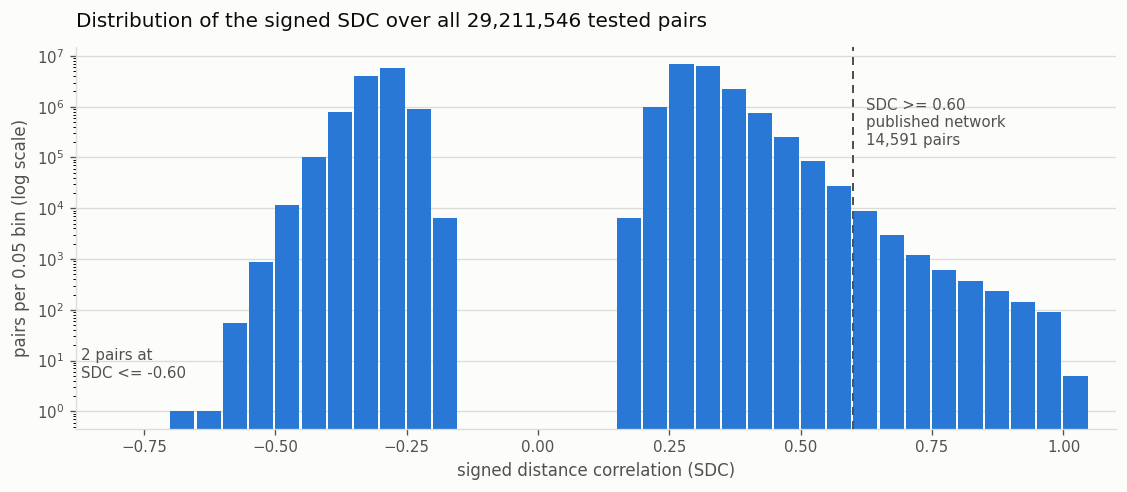

In [10]:
# Light chart surface with a recessive grid. A single series needs no legend, so the two values the
# reader must locate are labelled directly on the axes instead.
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dcdcd8"
SERIES_1, SERIES_2, SURFACE = "#2a78d6", "#eb6834", "#fcfcfb"

h = pd.read_csv(WORK / "s03_score_hist.csv").sort_values("bin")

fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=120, facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(h["bin"], h["c"], width=0.046, color=SERIES_1, linewidth=0, align="edge")
ax.set_yscale("log")
ax.axvline(0.60, color=INK_SOFT, linewidth=1.2, linestyle=(0, (4, 3)), zorder=3)

# Both labels sit in empty regions of the plot, so neither overlaps a bar: the cutoff label in the
# sparse upper right, the excluded-pairs label above the two single-pair bars on the far left.
n_net_edges = int(h.loc[h["bin"] >= 0.60, "c"].sum())
ax.text(0.625, 1.5e6, f"SDC >= 0.60\npublished network\n{n_net_edges:,} pairs",
        color=INK_SOFT, fontsize=9, ha="left", va="top")
# Counted from the data, not from the histogram bins: a bin labelled -0.60 holds scores in
# [-0.60, -0.55), which are not below the cutoff.
n_neg06 = con.execute(f"SELECT count(*) FROM '{RAWPQ}' WHERE Score <= -0.6").fetchone()[0]
ax.set_xlim(-0.88, 1.10)          # left margin so the label below clears the leftmost bars
ax.text(-0.87, 4, f"{n_neg06} pairs at\nSDC <= -0.60", color=INK_SOFT, fontsize=9,
        ha="left", va="bottom")

ax.set_xlabel("signed distance correlation (SDC)", color=INK_SOFT, fontsize=10)
ax.set_ylabel("pairs per 0.05 bin (log scale)", color=INK_SOFT, fontsize=10)
ax.set_title(f"Distribution of the signed SDC over all {n_raw:,} tested pairs",
             color=INK, fontsize=12, loc="left", pad=12)
ax.grid(axis="y", color=GRID, linewidth=0.8)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(GRID)
ax.tick_params(colors=INK_SOFT, labelsize=9)
fig.tight_layout()
fig.savefig(FIGDIR / "fig1_score_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()

---

## 4. Positional quality control against Swiss-Prot 2026_03

This is a stop condition for the whole analysis. If the residue at the stated position in the 2026_03
sequence did not match the residue in the PTM event identifier, the coordinates would come from a
different release and no site-level matching downstream could be trusted.

The check runs three ways, so the result cannot be an artefact of the reading convention: an exact
match at the stated 1-based position together with chemical compatibility with the modification, and
the same test at a one-residue shift in each direction.

In [11]:
import gzip

qc = pd.read_parquet(WORK / "posqc.parquet")
display(Markdown("**Positional QC status over all PTM events**"))
display(qc.status.value_counts().rename("events").to_frame())
print(f"mismatch rate (any status other than 'ok') = {100 * (qc.status != 'ok').mean():.3f}%  "
      f"({int((qc.status != 'ok').sum())} of {len(qc):,})")

seq, prim = {}, {}
with gzip.open(WORK / "sprot_human.jsonl.gz", "rt", encoding="utf-8") as fh:
    for ln in fh:
        r = json.loads(ln)
        for a in r["acc"]:
            prim[a] = r["acc"][0]
        seq[r["acc"][0]] = r["seq"]

need = set(qc.acc)
print(f"\nMoDPA proteins: {len(need):,}")
print(f"  not found in human Swiss-Prot 2026_03 : {len(need - set(prim))}")
print(f"  present but as a SECONDARY accession  : {sum(1 for a in need if a in prim and prim[a] != a)}")

display(Markdown("**Reading-convention probe: agreement at a shifted position**"))
probe = []
for k in (-1, 0, 1):
    c = 0
    for t in qc.itertuples():
        s = seq.get(prim.get(t.acc, ""), "")
        j = t.pos - 1 + k
        if s and 0 <= j < len(s) and s[j] == t.res:
            c += 1
    probe.append({"reading": {0: "1-based, as stated", -1: "0-based (pos-1)", 1: "shifted +1"}[k],
                  "events matching": c, "% of all events": round(100 * c / len(qc), 2)})
display(pd.DataFrame(probe))
print("The 1-based reading is confirmed empirically rather than assumed, and the stop condition on")
print("mismatch rate was not triggered.")

**Positional QC status over all PTM events**

,events
status,
ok,7644


mismatch rate (any status other than 'ok') = 0.000%  (0 of 7,644)

MoDPA proteins: 1,926
  not found in human Swiss-Prot 2026_03 : 0
  present but as a SECONDARY accession  : 0


**Reading-convention probe: agreement at a shifted position**

,reading,events matching,% of all events
0,0-based (pos-1),1141,14.93
1,"1-based, as stated",7644,100.00
2,shifted +1,1034,13.53


The 1-based reading is confirmed empirically rather than assumed, and the stop condition on
mismatch rate was not triggered.


---

## 5. Evidence base and tier definitions

The evidence base is built by streaming `uniprot_2026_03_sprot.dat.gz` once. Every extracted
statement retains its ECO codes and PubMed identifiers. No orthologue evidence is used, so nothing in
this analysis is non-human evidence.

| Tier | Definition as implemented |
|---|---|
| 1 | Both sites of the pair are cited by residue and position inside the **same** `CC -!- PTM:` block. Site-level explicit crosstalk. |
| 2 | Both sites carry a `MOD_RES` note naming the **same** enzyme (`; by X`), after splitting composite names such as `PKB/AKT1`. |
| 3 | Same protein, both sites annotated modified residues. |
| 4 | Different proteins, annotated as `CC INTERACTION` partners, as members of a shared CORUM or ComplexPortal complex, or named in one another's `CC SUBUNIT` text. |
| 5 | Both sites are annotated modified residues carrying an experimental ECO code, with no documented link between them. |
| unsupported | Everything else. |

Tiers 1, 2 and 4 are type (b) evidence, that the pair is linked. Tier 3 is type (b) only in the weak
sense of shared proteoform membership. **Tier 5 is purely type (a), that each site is individually a
known modification site, and is never presented as support for an association.**

A separate boolean column, `ptm_comment_names_partner`, records the weaker case in which one
protein's `CC PTM` block cites one site of the pair and names the gene symbol of the partner protein
without naming the partner site. That is a protein-level statement, not a site-level one, and it was
deliberately not folded into Tier 1.

In [12]:
S = pd.read_parquet(WORK / "ev_sites.parquet")
P = pd.read_parquet(WORK / "ev_ptmcc.parquet")
interact  = json.load(open(WORK / "ev_interact.json"))
complexes = json.load(open(WORK / "ev_complexes.json"))
subunit   = json.load(open(WORK / "ev_subunit.json"))
reactome  = json.load(open(WORK / "ev_reactome.json"))
htp       = json.load(open(WORK / "ev_htp_pmids.json"))

print(f"annotated feature positions on the MoDPA proteins: {len(S):,} over {S.acc.nunique():,} proteins")
display(S.ftype.value_counts().rename("feature positions").to_frame())
print(f"CC -!- PTM: comment blocks            : {len(P):,} on {P.acc.nunique():,} proteins")
print(f"proteins with CC SUBUNIT text         : {len(subunit):,}")
print(f"proteins with CC INTERACTION partners : {len(interact):,}")
print(f"proteins with CORUM / ComplexPortal   : {sum(1 for v in complexes.values() if v):,}")
print(f"proteins with Reactome cross-refs     : {sum(1 for v in reactome.values() if v):,}")
print(f"large-scale MS PubMed ids (ECO:0007744 / ECO:0000244 anywhere in human Swiss-Prot): "
      f"{len(htp['counts']):,}")

top = sorted(htp["counts"].items(), key=lambda x: -x[1])[:3]
display(Markdown("**The three most-used large-scale MS studies**"))
display(pd.DataFrame([{"PubMed": f"PubMed:{pm}", "uses": c, "title": htp["titles"].get(pm, "")[:95]}
                      for pm, c in top]))

annotated feature positions on the MoDPA proteins: 45,450 over 1,901 proteins


,feature positions
ftype,
MOD_RES,23506
DISULFID,10479
BINDING,6546
CROSSLNK,2863
CARBOHYD,835
SITE,778
ACT_SITE,343
LIPID,100


CC -!- PTM: comment blocks            : 1,830 on 982 proteins
proteins with CC SUBUNIT text         : 1,681
proteins with CC INTERACTION partners : 1,664
proteins with CORUM / ComplexPortal   : 1,069
proteins with Reactome cross-refs     : 1,378
large-scale MS PubMed ids (ECO:0007744 / ECO:0000244 anywhere in human Swiss-Prot): 2,390


**The three most-used large-scale MS studies**

,PubMed,uses,title
0,PubMed:23186163,8043,Toward a comprehensive characterization of a h...
1,PubMed:18669648,6546,A quantitative atlas of mitotic phosphorylation.
2,PubMed:28112733,3906,Site-specific mapping of the human SUMO proteo...


### Per-event annotation coverage, type (a)

Coverage is extremely uneven across modifications. This table is the reason the cluster-level result
in section 9.3 has to be read as a statement about UniProt coverage rather than about the clusters
themselves.

In [13]:
A = pd.read_parquet(WORK / "node_ann.parquet")
cov = (A.groupby("unimod")
         .agg(Events=("name", "size"), same_mod=("ann_samemod", "mean"),
              manual_exp=("ann_exp", "mean"), large_scale_MS=("ann_htp", "mean"))
         .assign(Modification=lambda d: d.index.map(lambda u: UNIMOD[u][0]))
         .sort_values("Events", ascending=False)
         .reset_index(drop=True))
cov = cov[["Modification", "Events", "same_mod", "manual_exp", "large_scale_MS"]]
cov.loc[len(cov)] = ["All", len(A), A.ann_samemod.mean(), A.ann_exp.mean(), A.ann_htp.mean()]
cov.columns = ["Modification", "Events", "Same-modification annotation",
               "Manual experimental (ECO:0000269)", "Large-scale MS (ECO:0007744/0000244)"]
display(fmt_table(cov, {"Same-modification annotation": "{:.1%}",
                          "Manual experimental (ECO:0000269)": "{:.1%}",
                          "Large-scale MS (ECO:0007744/0000244)": "{:.1%}"}))

print(f"\n{100 * A.ann_mod.mean():.1f}% of the {len(A):,} PTM events lie on an annotated modified "
      f"residue, and {100 * A.ann_samemod.mean():.1f}% carry an annotation of the same chemistry.")

t1a = pd.read_parquet(WORK / "pair_t1a.parquet")
t1b = pd.read_parquet(WORK / "pair_t1b.parquet")
t2  = pd.read_parquet(WORK / "pair_t2.parquet")
t4  = pd.read_parquet(WORK / "pair_t4.parquet")
print(f"\nTier 1a candidate pairs (site-level crosstalk)  : {len(t1a):,} PTM event pairs")
print(f"Tier 1b protein-level statements, NOT Tier 1   : {len(t1b):,}")
print(f"Tier 2 candidate pairs (shared enzyme)         : {len(t2):,}")
print(f"Tier 4 candidate protein pairs                 : {len(t4):,}")

,Modification,Events,Same-modification annotation,Manual experimental (ECO:0000269),Large-scale MS (ECO:0007744/0000244)
0,Phospho,6423,68.5%,6.9%,55.5%
1,Methyl,699,6.0%,12.0%,15.3%
2,Deamidated,267,2.6%,2.2%,0.0%
3,Dehydrated,77,0.0%,6.5%,20.8%
4,Acetyl,62,41.9%,27.4%,32.3%
5,HNE,43,0.0%,0.0%,11.6%
6,Carboxy,20,0.0%,5.0%,5.0%
7,GG_ubiquitin,20,70.0%,55.0%,5.0%
8,Dimethyl,19,73.7%,68.4%,73.7%
9,Trimethyl,11,63.6%,45.5%,36.4%



62.2% of the 7,644 PTM events lie on an annotated modified residue, and 59.0% carry an annotation of the same chemistry.

Tier 1a candidate pairs (site-level crosstalk)  : 114 PTM event pairs
Tier 1b protein-level statements, NOT Tier 1   : 1,224
Tier 2 candidate pairs (shared enzyme)         : 287
Tier 4 candidate protein pairs                 : 5,644


---

## 6. Tier distribution, with denominators

### 6.1 Significant versus non-significant pairs

Both significant and non-significant pairs are tiered, so the two can be compared. The comparison is
a negative result and is reported rather than suppressed: **significance alone carries no annotation
signal**, which is expected given that q < 0.05 retains 97% of the list.

In [14]:
d = con.execute(f"""SELECT tier, count(*) FILTER (is_sig) n_sig, count(*) FILTER (NOT is_sig) n_ns
                    FROM '{PT}' GROUP BY 1 ORDER BY 1""").df()
tot_s, tot_n = int(d.n_sig.sum()), int(d.n_ns.sum())
t61 = pd.DataFrame({
    "Tier": d.tier.map(TIER_LABEL),
    f"Significant (n = {tot_s:,})": d.n_sig.astype(int),
    "%": (100 * d.n_sig / tot_s).round(4),
    f"Non-significant (n = {tot_n:,})": d.n_ns.astype(int),
    " %": (100 * d.n_ns / tot_n).round(4),
})
sup_s, sup_n = int(d[d.tier <= 5].n_sig.sum()), int(d[d.tier <= 5].n_ns.sum())
t61.loc[len(t61)] = ["supported, tiers 1 to 5", sup_s, round(100 * sup_s / tot_s, 4),
                     sup_n, round(100 * sup_n / tot_n, 4)]
display(t61)
print(f"supported fraction: {100 * sup_s / tot_s:.3f}% among significant pairs against "
      f"{100 * sup_n / tot_n:.3f}% among non-significant pairs.")

,Tier,"Significant (n = 28,321,700)",%,"Non-significant (n = 889,846)",%
0,1 explicit crosstalk,85,0.0003,2,0.0002
1,2 shared regulator,215,0.0008,6,0.0007
2,3 same protein,22010,0.0777,513,0.0577
3,4 complex or interaction,133714,0.4721,4357,0.4896
4,5 both sites annotated,8636448,30.4941,272517,30.6252
5,unsupported,19529228,68.9550,612451,68.8266
6,"supported, tiers 1 to 5",8792472,31.0450,277395,31.1734


supported fraction: 31.045% among significant pairs against 31.173% among non-significant pairs.


### 6.2 Tier by |SDC| stratum and sign

No filtering beyond q < 0.05 is applied here or anywhere else. Pairs whose two sites can fall on one
tryptic peptide are flagged and counted, never removed: close-spaced phosphosite clusters are a
documented biological phenomenon and cannot be separated from co-quantification artefacts by a
sequence rule. The `copep` column gives the co-quantifiable rate in each cell so that the
contribution is visible.

`%T1-4` is the association-level support rate. `%T1-5` adds the type (a) tier.

In [15]:
t62 = con.execute(f"""
 SELECT stratum, sign, count(*) AS Pairs,
        count(*) FILTER (tier = 1) AS T1, count(*) FILTER (tier = 2) AS T2,
        count(*) FILTER (tier = 3) AS T3, count(*) FILTER (tier = 4) AS T4,
        count(*) FILTER (tier = 5) AS T5,
        100.0 * count(*) FILTER (tier <= 4) / count(*) AS "%T1-4",
        100.0 * count(*) FILTER (tier <= 5) / count(*) AS "%T1-5",
        100.0 * count(*) FILTER (same_peptide) / count(*) AS "copep %"
 FROM '{PT}' WHERE is_sig GROUP BY 1, 2 ORDER BY 1, 2""").df()
t62.insert(0, "Stratum", t62.pop("stratum").map(STRATUM_LABEL))
display(fmt_table(t62, {"Pairs": "{:,.0f}", "T1": "{:,.0f}", "T2": "{:,.0f}", "T3": "{:,.0f}",
                          "T4": "{:,.0f}", "T5": "{:,.0f}", "%T1-4": "{:.3f}", "%T1-5": "{:.2f}",
                          "copep %": "{:.3f}"}))

pos = t62[t62["sign"] == "pos"].sort_values("Stratum")
lo, hi = pos["%T1-4"].iloc[0], pos["%T1-4"].iloc[-1]
print(f"Association-level support among positive pairs rises from {lo:.3f}% in the lowest stratum to "
      f"{hi:.3f}% in the highest, a factor of {hi / lo:.0f}.")
print("Among negative pairs it does not rise. The type (a) rate (%T1-5) is flat for positives and")
print("falls for negatives, confirming that it is not a useful discriminator.\n")
print("Co-quantifiable pairs are at most 0.2% of every stratum below 0.55, so they cannot explain the")
print("rise from S01 to S08. They become material only in the top two strata, which is exactly where")
print("the published network lives. The corresponding table with those pairs dropped is in")
print("work/s18_tier_stratum_nocop.csv; it is a sensitivity check, not the result.")

,Stratum,sign,Pairs,T1,T2,T3,T4,T5,%T1-4,%T1-5,copep %
0,S01 <0.25,neg,"508,363",1,5,249,"2,099","150,104",0.463,29.99,0.006
1,S01 <0.25,pos,"541,830",0,6,373,"2,594","168,357",0.549,31.62,0.010
2,S02 0.25-0.30,neg,"5,767,591",5,26,"2,621","24,523","1,691,797",0.471,29.80,0.005
3,S02 0.25-0.30,pos,"6,814,591",11,45,"4,540","32,959","2,142,989",0.551,32.00,0.010
4,S03 0.30-0.35,neg,"4,056,929",2,24,"1,581","16,554","1,147,986",0.448,28.74,0.005
5,S03 0.30-0.35,pos,"6,327,894",15,60,"4,956","31,246","2,001,098",0.573,32.20,0.015
6,S04 0.35-0.40,neg,"770,592",0,2,247,"2,975","204,310",0.418,26.93,0.005
7,S04 0.35-0.40,pos,"2,272,139",7,20,"2,702","12,477","732,944",0.669,32.93,0.034
8,S05 0.40-0.45,neg,"103,179",0,0,30,376,"25,468",0.393,25.08,0.004
9,S05 0.40-0.45,pos,"759,358",4,8,"1,450","4,595","248,736",0.798,33.55,0.072


Association-level support among positive pairs rises from 0.549% in the lowest stratum to 32.058% in the highest, a factor of 58.
Among negative pairs it does not rise. The type (a) rate (%T1-5) is flat for positives and
falls for negatives, confirming that it is not a useful discriminator.

Co-quantifiable pairs are at most 0.2% of every stratum below 0.55, so they cannot explain the
rise from S01 to S08. They become material only in the top two strata, which is exactly where
the published network lives. The corresponding table with those pairs dropped is in
work/s18_tier_stratum_nocop.csv; it is a sensitivity check, not the result.


---

## 7. Built-in controls

### 7.1 Competing modifications at the same residue: the prediction fails

Lysine can carry acetyl, ubiquityl, methyl and succinyl marks that cannot coexist at a given moment.
If MoDPA detected mutual exclusivity, pairs of competing marks on one residue should be enriched for
negative SDC. They are not. They are significantly **less** negative than every reference class.

In [16]:
from scipy.stats import fisher_exact

CLASSES = [
  ("Same residue, different modification",
   "same_site AND modA <> modB"),
  ("Same protein, co-quantified, different modification",
   "same_protein AND same_peptide AND NOT same_site AND modA <> modB"),
  ("Same protein, co-quantified, same modification",
   "same_protein AND same_peptide AND NOT same_site AND modA = modB"),
  ("Same protein, not co-quantified, different modification",
   "same_protein AND NOT same_peptide AND modA <> modB"),
  ("Different proteins, different modification",
   "NOT same_protein AND modA <> modB"),
  ("All significant pairs", "TRUE"),
]
res, rows = {}, []
for lab, w in CLASSES:
    n, neg, m = con.execute(f"SELECT count(*), count(*) FILTER (sign = 'neg'), avg(Score) "
                            f"FROM '{PT}' WHERE is_sig AND {w}").fetchone()
    res[lab] = (n, neg)
    rows.append({"Pair class": lab, "n": n, "Negative": neg,
                 "% negative": round(100 * neg / n, 1), "Mean SDC": round(m, 3)})
display(pd.DataFrame(rows))

a = res["Same residue, different modification"]
ftest = []
for ref in ["Same protein, not co-quantified, different modification",
            "Different proteins, different modification"]:
    b = res[ref]
    tab = [[a[1], a[0] - a[1]], [b[1], b[0] - b[1]]]
    ftest.append({"reference class": ref,
                  "p, same-residue MORE negative (the prediction)": fisher_exact(tab, alternative="greater")[1],
                  "p, same-residue LESS negative": fisher_exact(tab, alternative="less")[1]})
display(Markdown("**Fisher exact tests, one-tailed in each direction**"))
display(fmt_table(pd.DataFrame(ftest), {"p, same-residue MORE negative (the prediction)": "{:.3g}",
                                          "p, same-residue LESS negative": "{:.3g}"}))

det = pd.read_csv(WORK / "s14_same_residue_pairs.csv")
print(f"\n{len(det)} same-residue, different-modification significant pairs; "
      f"{int(det.in_network.sum())} of them are in the published network.")
print("most frequent modification combinations:",
      det.groupby(["modA_name", "modB_name"]).size().sort_values(ascending=False).head(3).to_dict())
print("\nBoth readings must be stated. Occupancy is a bounded ratio computed from PSM counts at one")
print("site, so some anticorrelation between competing marks could in principle be induced by the")
print("quantification. That mechanism would push the result toward negative SDC and the observation")
print("goes the other way, so it cannot explain what is seen. The explanation that does fit is shared")
print("measurement: two marks on one residue are always measured from overlapping PSM sets. The")
print("same-residue signal is therefore dominated by co-quantification and is not usable as evidence")
print("that MoDPA detects mutual exclusivity. With n = 71 the test is also underpowered.")

,Pair class,n,Negative,% negative,Mean SDC
0,"Same residue, different modification",71,7,9.9,0.344
1,"Same protein, co-quantified, different modific...",620,104,16.8,0.287
2,"Same protein, co-quantified, same modification",7329,475,6.5,0.487
3,"Same protein, not co-quantified, different mod...",6478,1906,29.4,0.156
4,"Different proteins, different modification",8017598,3531413,44.0,0.043
5,All significant pairs,28321700,11219065,39.6,0.073


**Fisher exact tests, one-tailed in each direction**

,reference class,"p, same-residue MORE negative (the prediction)","p, same-residue LESS negative"
0,"Same protein, not co-quantified, different mod...",1,7.48e-05
1,"Different proteins, different modification",1,3.59e-10



71 same-residue, different-modification significant pairs; 9 of them are in the published network.
most frequent modification combinations: {('Acetyl', 'Methyl'): 21, ('Phospho', 'Dehydrated'): 16, ('Methyl', 'Dimethyl'): 7}

Both readings must be stated. Occupancy is a bounded ratio computed from PSM counts at one
site, so some anticorrelation between competing marks could in principle be induced by the
quantification. That mechanism would push the result toward negative SDC and the observation
goes the other way, so it cannot explain what is seen. The explanation that does fit is shared
measurement: two marks on one residue are always measured from overlapping PSM sets. The
same-residue signal is therefore dominated by co-quantification and is not usable as evidence
that MoDPA detects mutual exclusivity. With n = 71 the test is also underpowered.


### 7.2 Shared-measurement flag: reported, not applied

Pairs whose two sites can fall on one tryptic peptide are quantified from overlapping PSM sets, so
their correlation can reflect shared measurement rather than coordination. This is reported as a flag
and is never used as a filter.

The evidence that the flag would discard real biology is direct: a majority of the Tier 1 pairs,
which UniProt explicitly documents as crosstalk in a `CC PTM` comment, are co-quantifiable. A
proximity or peptide filter removes all of them.

The cell below also decodes the control flags shipped inside the filtered-network file, and shows
that the provided `shared_peptide` column is a fixed 5-residue proximity rule rather than a tryptic
calculation.

In [17]:
T = pd.read_parquet(WORK / "ev_tryptic.parquet")
print("Trypsin, up to two missed cleavages, no cleavage before proline, computed from the 2026_03 sequences.\n")
print(f"same-protein PTM event pairs in total           : {len(T):,}")
print(f"  can fall on one tryptic peptide               : {int(T.same_peptide_std.sum()):,}")
print(f"  same, modified K/R treated as non-cleavable   : {int(T.same_peptide_modblocked.sum()):,}  (upper bound)")

r = con.execute(f"""SELECT count(*) FILTER (same_protein),
   count(*) FILTER (same_protein AND same_peptide),
   count(*) FILTER (same_protein AND same_peptide AND same_mod)
   FROM '{PT}' WHERE is_sig""").fetchone()
print(f"\namong significant pairs: {r[0]:,} are same-protein, {r[1]:,} can fall on one peptide, "
      f"of which {r[2]:,} carry the same modification")

n = con.execute(f"SELECT count(*), count(*) FILTER (same_peptide) FROM '{PT}' WHERE in_network").fetchone()
print(f"published network: {n[1]:,} of {n[0]:,} edges ({100 * n[1] / n[0]:.1f}%) are co-quantifiable, "
      f"against {r[1]:,} of {tot_s:,} ({100 * r[1] / tot_s:.2f}%) in the significant list as a whole")

b = con.execute(f"""SELECT avg(Score) FILTER (same_peptide),
   avg(Score) FILTER (same_protein AND NOT same_peptide),
   100.0 * count(*) FILTER (same_peptide AND sign = 'neg') / count(*) FILTER (same_peptide),
   100.0 * count(*) FILTER (sign = 'neg') / count(*) FROM '{PT}' WHERE is_sig""").fetchone()
print(f"mean SDC: co-quantified {b[0]:+.3f} against {b[1]:+.3f} for same-protein pairs that cannot share a peptide")
print(f"negative fraction: co-quantified {b[2]:.1f}% against {b[3]:.1f}% overall")

t1 = pd.read_csv(WORK / "s20_tier1_pairs.csv")
print(f"\nTier 1 significant pairs: {len(t1)}; co-quantifiable {int(t1.same_peptide.sum())}; "
      f"in the published network {int(t1.in_network.sum())}")
display(Markdown("**The highest-scoring Tier 1 pairs, all documented, most of them co-quantifiable**"))
display(t1.head(8)[["geneA", "nodeA", "nodeB", "Score", "stratum", "in_network",
                    "same_peptide", "position_gap"]])
print("Every one of these is documented, and a proximity or peptide filter removes all of them.")

display(Markdown("**Decoding the control flags shipped in the filtered-network file**"))
fd = net_df.to_pandas()
fd["k"] = fd.nodeA + "__" + fd.nodeB
Tk = T.assign(k=T.nodeA + "__" + T.nodeB)
mm = fd.merge(Tk[["k", "same_peptide_std", "position_gap"]], on="k", how="left", suffixes=("", "_mine"))
sp = mm[mm.same_protein]
rule5 = (sp.position_gap <= 5)
print(f"provided shared_peptide reproduced by 'same protein AND position_gap <= 5' : "
      f"{100 * (sp.shared_peptide == rule5).mean():.1f}% of {len(sp):,} same-protein rows")
print(f"provided potential_artefact reproduced by 'shared_peptide AND same_mod'    : "
      f"{100 * (fd.potential_artefact == (fd.shared_peptide & fd.same_mod)).mean():.1f}% of {len(fd):,} rows")
print(f"the recomputed tryptic rule flags {int(mm.same_peptide_std.fillna(False).sum()):,} network edges "
      f"against {int(fd.shared_peptide.sum()):,} for the provided flag")
print("The provided flag is a fixed 5-residue proximity rule, not a tryptic calculation. This")
print("analysis uses the recomputed tryptic rule throughout, as ctrl_shared_tryptic_peptide.")

Trypsin, up to two missed cleavages, no cleavage before proline, computed from the 2026_03 sequences.

same-protein PTM event pairs in total           : 51,760
  can fall on one tryptic peptide               : 9,532
  same, modified K/R treated as non-cleavable   : 10,118  (upper bound)

among significant pairs: 50,541 are same-protein, 8,010 can fall on one peptide, of which 7,329 carry the same modification
published network: 2,780 of 14,591 edges (19.1%) are co-quantifiable, against 8,010 of 28,321,700 (0.03%) in the significant list as a whole
mean SDC: co-quantified +0.470 against +0.163 for same-protein pairs that cannot share a peptide
negative fraction: co-quantified 7.3% against 39.6% overall

Tier 1 significant pairs: 85; co-quantifiable 61; in the published network 28


**The highest-scoring Tier 1 pairs, all documented, most of them co-quantifiable**

,geneA,nodeA,nodeB,Score,stratum,in_network,same_peptide,position_gap
0,ZC3HAV1,Q7Z2W4|263|S|21,Q7Z2W4|267|S|21,0.998059,S10_0.70+,True,True,4
1,HSF1,Q00613|319|S|21,Q00613|320|S|21,0.983469,S10_0.70+,True,True,1
2,XRCC4,Q13426|327|S|21,Q13426|328|S|21,0.903452,S10_0.70+,True,True,1
3,HSF1,Q00613|314|S|21,Q00613|320|S|21,0.811731,S10_0.70+,True,True,6
4,HDAC1,Q13547|421|S|21,Q13547|423|S|21,0.803442,S10_0.70+,True,True,2
5,PRKCD,Q05655|313|Y|21,Q05655|334|Y|21,0.785466,S10_0.70+,True,True,21
6,HSF1,Q00613|314|S|21,Q00613|319|S|21,0.772499,S10_0.70+,True,True,5
7,NIBAN2,Q96TA1|692|S|21,Q96TA1|696|S|21,0.770842,S10_0.70+,True,True,4


Every one of these is documented, and a proximity or peptide filter removes all of them.


**Decoding the control flags shipped in the filtered-network file**

provided shared_peptide reproduced by 'same protein AND position_gap <= 5' : 100.0% of 3,195 same-protein rows
provided potential_artefact reproduced by 'shared_peptide AND same_mod'    : 100.0% of 14,591 rows
the recomputed tryptic rule flags 2,780 network edges against 2,425 for the provided flag
The provided flag is a fixed 5-residue proximity rule, not a tryptic calculation. This
analysis uses the recomputed tryptic rule throughout, as ctrl_shared_tryptic_peptide.


---

## 8. Background comparison and monotonicity

An enrichment claim needs a matched null, because well-studied proteins accumulate annotations and
detections together.

**Null construction.** A node-level matched permutation. Each PTM event is binned on modification
type, detection-frequency decile, and annotation-density decile of its protein. Bins are coarsened
when fewer than 5 nodes are available. For each observed pair, each endpoint is replaced by a random
node drawn from its own bin, the resampled pair is discarded only if it is a self pair, and the tier
is recomputed. 1,000 permutations per cell, seeded with 42.

**Sampling.** The observed sample is a seeded reservoir sample of up to 200,000 pairs per cell, so
the run is deterministic. The `exact` column is the support rate over the complete stratum with no
sampling at all, and is the figure to quote; `obs` is the sampled value, present only because the
null is computed on the same sample.

**Tests.** Every p-value here is an empirical permutation p-value, not a t-test, and makes no
distributional assumption. `p up` is one-tailed on the upper tail (enrichment), `p lo` one-tailed on
the lower tail (depletion), and `p 2s` the doubled smaller tail. Each uses the add-one correction, so
the attainable floor is 1/1001, shown as 0.001.

In [18]:
R = pd.read_csv(WORK / "s15_background.csv")
t81 = pd.DataFrame({
    "Stratum": R.stratum.map(STRATUM_LABEL), "Sign": R["sign"],
    "exact": R.exact_T1_4_full_stratum, "m tested": R.m_tested,
    "obs": R.obs_T1_4, "null": R.null_T1_4, "ratio": R.ratio_T1_4,
    "p up": R.p_T1_4, "p lo": R.p_T1_4_lower, "p 2s": R.p_T1_4_two_sided,
    "copep": R.frac_copeptide_in_sample,
    "T1-4 if copep dropped": R.obs_T1_4_sensitivity_copeptide_dropped,
}).sort_values(["Stratum", "Sign"]).reset_index(drop=True)

display(fmt_table(t81, {"exact": "{:.5f}", "m tested": "{:,.0f}", "obs": "{:.5f}",
                        "null": "{:.5f}", "ratio": "{:.2f}", "p up": "{:.3f}", "p lo": "{:.3f}",
                        "p 2s": "{:.3f}", "copep": "{:.2%}", "T1-4 if copep dropped": "{:.5f}"}))

print("Where m equals the stratum size the whole stratum was used, so exact and obs coincide.")
print("The two negative pairs above 0.6 are too few to test and are omitted.\n")

en_rows = t81[(t81.Sign == "pos") & (t81["p up"] <= 0.05)]
de_rows = t81[(t81.Sign == "neg") & (t81["p lo"] <= 0.05)]
print(f"positive strata significantly ENRICHED on the upper tail : {len(en_rows)}  "
      f"({', '.join(en_rows.Stratum)})")
print(f"negative strata significantly DEPLETED on the lower tail : {len(de_rows)}  "
      f"({', '.join(de_rows.Stratum)})")
print("\nPositive SDC behaves as a meaningful score: support sits at the matched null in the lowest")
print("strata, then rises without a single reversal to the top of the range.")
print("\nNegative SDC is not merely un-enriched, it is significantly depleted. A negative SDC actively")
print("predicts that a pair is LESS likely to be documented than a random pair matched on")
print("modification type, detection frequency and annotation density. That is a stronger and more")
print("useful statement than an absence of enrichment, and it was invisible in an earlier version of")
print("this analysis that tested only the upper tail.")

s09 = t81[(t81.Sign == "pos") & (t81.Stratum.str.startswith("S09"))].iloc[0]
s10 = t81[(t81.Sign == "pos") & (t81.Stratum.str.startswith("S10"))].iloc[0]
print("\nSensitivity in the two strata where co-quantification is material:")
for s in (s09, s10):
    print(f"  {s.Stratum}: co-quantifiable {s.copep:.1%}; ratio {s.ratio:.2f}x falls to about "
          f"{s['T1-4 if copep dropped'] / s['null']:.1f}x when those pairs are dropped, "
          f"still well above the null")

,Stratum,Sign,exact,m tested,obs,null,ratio,p up,p lo,p 2s,copep,T1-4 if copep dropped
0,S01 <0.25,neg,0.00463,"200,000",0.00470,0.00528,0.89,1.000,0.001,0.002,0.01%,0.00468
1,S01 <0.25,pos,0.00549,"200,000",0.00571,0.00557,1.02,0.210,0.791,0.420,0.01%,0.00564
2,S02 0.25-0.30,neg,0.00471,"200,000",0.00487,0.00522,0.93,0.987,0.014,0.028,0.01%,0.00485
3,S02 0.25-0.30,pos,0.00551,"200,000",0.00556,0.00551,1.01,0.391,0.610,0.781,0.02%,0.00550
4,S03 0.30-0.35,neg,0.00448,"200,000",0.00456,0.00507,0.90,1.000,0.001,0.002,0.01%,0.00455
5,S03 0.30-0.35,pos,0.00573,"200,000",0.00562,0.00564,1.00,0.538,0.463,0.925,0.02%,0.00552
6,S04 0.35-0.40,neg,0.00418,"200,000",0.00414,0.00484,0.86,1.000,0.001,0.002,0.01%,0.00412
7,S04 0.35-0.40,pos,0.00669,"200,000",0.00648,0.00590,1.10,0.001,1.000,0.002,0.04%,0.00632
8,S05 0.40-0.45,neg,0.00393,"103,179",0.00393,0.00459,0.86,0.998,0.003,0.006,0.00%,0.00394
9,S05 0.40-0.45,pos,0.00798,"200,000",0.00815,0.00642,1.27,0.001,1.000,0.002,0.08%,0.00778


Where m equals the stratum size the whole stratum was used, so exact and obs coincide.
The two negative pairs above 0.6 are too few to test and are omitted.

positive strata significantly ENRICHED on the upper tail : 7  (S04 0.35-0.40, S05 0.40-0.45, S06 0.45-0.50, S07 0.50-0.55, S08 0.55-0.60, S09 0.60-0.70, S10 >=0.70)
negative strata significantly DEPLETED on the lower tail : 5  (S01 <0.25, S02 0.25-0.30, S03 0.30-0.35, S04 0.35-0.40, S05 0.40-0.45)

Positive SDC behaves as a meaningful score: support sits at the matched null in the lowest
strata, then rises without a single reversal to the top of the range.

Negative SDC is not merely un-enriched, it is significantly depleted. A negative SDC actively
predicts that a pair is LESS likely to be documented than a random pair matched on
modification type, detection frequency and annotation density. That is a stronger and more
useful statement than an absence of enrichment, and it was invisible in an earlier version of
this analysis that

### Figure 2. Support rate against the matched null

The two panels are the same measurement on positive and on negative associations. Both share one
logarithmic rate axis, so the panels can be read against one another. This is a rendering of the
`exact` and `null` columns of the table above; the observed series is the exact full-stratum rate,
which is the figure the report quotes.

Observed points are filled where the stratum differs from its matched null at two-sided p <= 0.05
and open where it does not. The open points are the small strata, so the apparent rise in the last
negative band, which holds 55 pairs, is marked as untestable rather than left to be read as a trend.

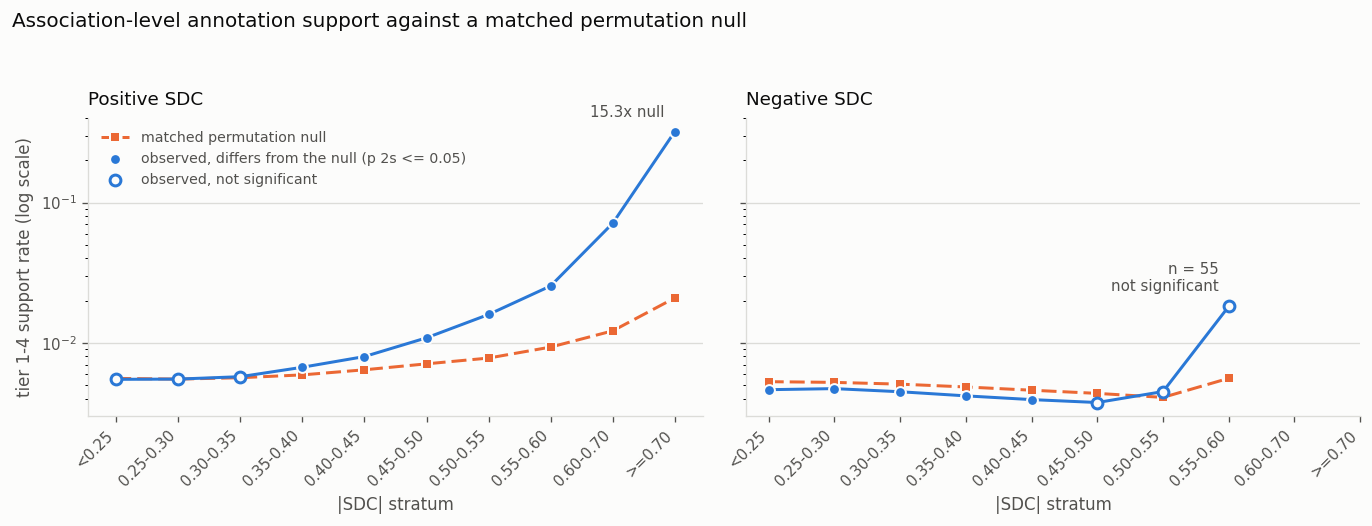

In [19]:
order = sorted(STRATUM_LABEL)
xpos = {s: i for i, s in enumerate(order)}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), dpi=120, sharey=True, facecolor=SURFACE)

for ax, sg, title in zip(axes, ["pos", "neg"], ["Positive SDC", "Negative SDC"]):
    sub = R[R["sign"] == sg].copy()
    sub["x"] = sub.stratum.map(xpos)
    sub = sub.sort_values("x")
    sig = (sub.p_T1_4_two_sided <= 0.05).to_numpy()
    ax.set_facecolor(SURFACE)
    ax.plot(sub.x, sub.null_T1_4, color=SERIES_2, linewidth=1.8, linestyle=(0, (5, 2)), marker="s",
            markersize=5.5, markeredgecolor=SURFACE, markeredgewidth=1.2,
            label="matched permutation null", zorder=2)
    ax.plot(sub.x, sub.exact_T1_4_full_stratum, color=SERIES_1, linewidth=1.8, zorder=3)
    # Filled where the stratum differs from its null at two-sided p <= 0.05, open where it does not.
    # The open points are the small strata, so the reader is not invited to read a tail that the
    # permutation test cannot support.
    ax.scatter(sub.x[sig], sub.exact_T1_4_full_stratum[sig], s=42, color=SERIES_1, zorder=4,
               edgecolor=SURFACE, linewidth=1.2, label="observed, differs from the null (p 2s <= 0.05)")
    ax.scatter(sub.x[~sig], sub.exact_T1_4_full_stratum[~sig], s=42, facecolor=SURFACE, zorder=4,
               edgecolor=SERIES_1, linewidth=1.8, label="observed, not significant")
    last = sub.iloc[-1]
    ax.annotate(f"{last.ratio_T1_4:.1f}x null" if sg == "pos"
                else f"n = {int(last.n_stratum)}\nnot significant",
                xy=(last.x, last.exact_T1_4_full_stratum), xytext=(-6, 9),
                textcoords="offset points", color=INK_SOFT, fontsize=9, ha="right")
    ax.set_yscale("log")
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([STRATUM_LABEL[s].split(" ", 1)[1] for s in order], rotation=45, ha="right",
                       fontsize=8.5)
    ax.set_title(title, color=INK, fontsize=11, loc="left", pad=8)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(GRID)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    ax.set_xlabel("|SDC| stratum", color=INK_SOFT, fontsize=10)

axes[0].set_ylabel("tier 1-4 support rate (log scale)", color=INK_SOFT, fontsize=10)
axes[0].legend(frameon=False, fontsize=8.5, labelcolor=INK_SOFT, loc="upper left")
fig.suptitle("Association-level annotation support against a matched permutation null",
             color=INK, fontsize=12, x=0.01, ha="left", y=0.985)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGDIR / "fig2_support_vs_null.png", dpi=150, facecolor=SURFACE)
plt.show()

### 8.2 Monotonicity

Spearman rank correlation of each quantity against the ordered strata, with a two-sided permutation
p-value: exact enumeration of all 40,320 orderings where 8 strata are available, and 200,000 random
shuffles where 10 are.

The default `spearmanr` p-value is deliberately not used. It comes from a t-approximation whose
denominator vanishes as the absolute rho approaches 1, and at rho = +1.000 it returned 6.6e-64. That
value is not attainable: with ten points the smallest possible two-sided p is 2/10! = 5.5e-7.

In [20]:
M = pd.read_csv(WORK / "s24_monotonicity.csv")
t82 = M[["sign", "label", "rho", "p", "mode"]].rename(
        columns={"sign": "Sign", "label": "Metric", "rho": "rho", "p": "p", "mode": "test"})
t82["Sign"] = t82.Sign.map({"pos": "positive", "neg": "negative"})
t82["at the floor"] = M.p <= M.p_floor * 1.5
display(fmt_table(t82, {"rho": "{:+.3f}", "p": "{:.3g}"}))

mono = lambda sg, met, col: M[(M["sign"] == sg) & (M.metric == met)][col].iloc[0]
print(f"positive, exact tier 1-4 rate : rho = {mono('pos', 'exact_T1_4_full_stratum', 'rho'):+.3f}, "
      f"p = {mono('pos', 'exact_T1_4_full_stratum', 'p'):.2g}")
print("  A perfectly monotone increase across all ten bands, with no reversal.")
print(f"negative, exact tier 1-4 rate : rho = {mono('neg', 'exact_T1_4_full_stratum', 'rho'):+.3f}, "
      f"p = {mono('neg', 'exact_T1_4_full_stratum', 'p'):.2f}")
print("  No trend with the absolute SDC among negative pairs.")
print(f"positive, type (a) T1-5 rate  : rho = {mono('pos', 'obs_T1_5', 'rho'):+.3f}, "
      f"p = {mono('pos', 'obs_T1_5', 'p'):.2f}")
print("  The type (a) rate carries no information: it is flat across the positive strata and holds")
print("  for about 31% of the significant list, the non-significant list and the matched background alike.")

,Sign,Metric,rho,p,test,at the floor
0,positive,"exact T1-4 rate, full stratum",+1.000,5e-06,"Monte Carlo (200,000 shuffles)",True
1,positive,"observed T1-4 rate, sample",+0.964,5e-05,"Monte Carlo (200,000 shuffles)",False
2,positive,ratio to matched null,+0.952,0.000145,"Monte Carlo (200,000 shuffles)",False
3,positive,observed T1-2 rate,+0.960,3.5e-05,"Monte Carlo (200,000 shuffles)",False
4,positive,"observed T1-5 rate, type (a)",+0.091,0.81,"Monte Carlo (200,000 shuffles)",False
5,negative,"exact T1-4 rate, full stratum",-0.071,0.882,"exact (40,320 orderings)",False
6,negative,"observed T1-4 rate, sample",-0.167,0.703,"exact (40,320 orderings)",False
7,negative,ratio to matched null,+0.333,0.428,"exact (40,320 orderings)",False
8,negative,observed T1-2 rate,-0.874,0.00952,"exact (40,320 orderings)",False
9,negative,"observed T1-5 rate, type (a)",-1.000,4.96e-05,"exact (40,320 orderings)",False


positive, exact tier 1-4 rate : rho = +1.000, p = 5e-06
  A perfectly monotone increase across all ten bands, with no reversal.
negative, exact tier 1-4 rate : rho = -0.071, p = 0.88
  No trend with the absolute SDC among negative pairs.
positive, type (a) T1-5 rate  : rho = +0.091, p = 0.81
  The type (a) rate carries no information: it is flat across the positive strata and holds
  for about 31% of the significant list, the non-significant list and the matched background alike.


---

## 9. Mapping onto the published network and the clusters

### 9.1 Retention at SDC >= 0.6

Retention is strongly tier-ordered. That ordering is the clearest single statement that the score
tracks documented biology.

In [21]:
ret  = pd.read_csv(WORK / "s16_retention_all.csv")
retn = pd.read_csv(WORK / "s16_retention_nocop.csv")
t91 = pd.DataFrame({"Tier": ret.tier.map(TIER_LABEL), "Significant": ret.n,
                    "In network": ret.n_in, "Below 0.6": ret.n_out,
                    "Retained": 100 * ret.n_in / ret.n})
display(fmt_table(t91, {"Significant": "{:,.0f}", "In network": "{:,.0f}",
                          "Below 0.6": "{:,.0f}", "Retained": "{:.3f}%"}))

above = int(ret[ret.tier <= 4].n_in.sum()); below = int(ret[ret.tier <= 4].n_out.sum())
t12a = int(ret[ret.tier <= 2].n_in.sum()); t12b = int(ret[ret.tier <= 2].n_out.sum())
print(f"association-level supported pairs (tiers 1 to 4): {above:,} at or above 0.6, {below:,} below it")
print(f"strictest tiers 1 and 2: {t12a} above, {t12b} below")
r1 = t91.loc[t91.Tier.str.startswith("1"), "Retained"].iloc[0]
r4 = t91.loc[t91.Tier.str.startswith("4"), "Retained"].iloc[0]
r9 = t91.loc[t91.Tier == "unsupported", "Retained"].iloc[0]
print(f"\none Tier 1 pair in {100 / r1:.0f} survives the cutoff, against one Tier 4 pair in "
      f"{100 / r4:.0f} and one unsupported pair in {100 / r9:.0f}")

display(Markdown("**Sensitivity check only: the same view with co-quantifiable pairs dropped**"))
tn = pd.DataFrame({"Tier": retn.tier.map(TIER_LABEL), "Significant": retn.n,
                   "In network": retn.n_in, "Retained": 100 * retn.n_in / retn.n})
display(fmt_table(tn, {"Significant": "{:,.0f}", "In network": "{:,.0f}", "Retained": "{:.3f}%"}))
print("This is reported as a sensitivity check and not as the result, because these are exactly the")
print("pairs UniProt documents as crosstalk.")

display(Markdown("**Retained Tier 1 pairs: the documented crosstalk that survives the cutoff**"))
t1net = pd.read_csv(WORK / "s20_tier1_pairs.csv").query("in_network").sort_values("Score", ascending=False)
display(t1net[["geneA", "geneB", "nodeA", "nodeB", "Score", "same_peptide", "position_gap"]].head(10))
print(f"{int(t1net.same_peptide.sum())} of the {len(t1net)} retained Tier 1 pairs are co-quantifiable.")

,Tier,Significant,In network,Below 0.6,Retained
0,1 explicit crosstalk,85,28,57,32.941%
1,2 shared regulator,215,4,211,1.860%
2,3 same protein,"22,010","1,446","20,564",6.570%
3,4 complex or interaction,"133,714",226,"133,488",0.169%
4,5 both sites annotated,"8,636,448","2,520","8,633,928",0.029%
5,unsupported,"19,529,228","10,367","19,518,861",0.053%


association-level supported pairs (tiers 1 to 4): 1,704 at or above 0.6, 154,320 below it
strictest tiers 1 and 2: 32 above, 268 below

one Tier 1 pair in 3 survives the cutoff, against one Tier 4 pair in 592 and one unsupported pair in 1884


**Sensitivity check only: the same view with co-quantifiable pairs dropped**

,Tier,Significant,In network,Retained
0,1 explicit crosstalk,24,2,8.333%
1,2 shared regulator,201,2,0.995%
2,3 same protein,"18,511",156,0.843%
3,4 complex or interaction,"133,714",226,0.169%
4,5 both sites annotated,"8,636,448","2,520",0.029%
5,unsupported,"19,524,792","8,905",0.046%


This is reported as a sensitivity check and not as the result, because these are exactly the
pairs UniProt documents as crosstalk.


**Retained Tier 1 pairs: the documented crosstalk that survives the cutoff**

,geneA,geneB,nodeA,nodeB,Score,same_peptide,position_gap
0,ZC3HAV1,ZC3HAV1,Q7Z2W4|263|S|21,Q7Z2W4|267|S|21,0.998059,True,4
1,HSF1,HSF1,Q00613|319|S|21,Q00613|320|S|21,0.983469,True,1
2,XRCC4,XRCC4,Q13426|327|S|21,Q13426|328|S|21,0.903452,True,1
3,HSF1,HSF1,Q00613|314|S|21,Q00613|320|S|21,0.811731,True,6
4,HDAC1,HDAC1,Q13547|421|S|21,Q13547|423|S|21,0.803442,True,2
5,PRKCD,PRKCD,Q05655|313|Y|21,Q05655|334|Y|21,0.785466,True,21
6,HSF1,HSF1,Q00613|314|S|21,Q00613|319|S|21,0.772499,True,5
7,NIBAN2,NIBAN2,Q96TA1|692|S|21,Q96TA1|696|S|21,0.770842,True,4
8,MAPT,MAPT,P10636|713|S|21,P10636|717|S|21,0.768689,True,4
9,CEP55,CEP55,Q53EZ4|428|S|21,Q53EZ4|436|S|21,0.768126,True,8


26 of the 28 retained Tier 1 pairs are co-quantifiable.


### 9.2 Cluster capture

Cluster labels throughout come from the weighted Leiden partition in
`20260911-True-data-Leiden-clusters.csv`, joined to the network edges on the PTM event identifier.
Every edge endpoint carries a label, so nothing is dropped by the join.

Clustering loses very little of what survives the score cutoff. Splitting across clusters is
therefore a much smaller source of loss than the score cutoff itself, and the two are reported
separately rather than pooled.

In [22]:
cap = pd.read_csv(WORK / "s16_cluster_capture.csv")
t92 = pd.DataFrame({"Tier": cap.tier.map(TIER_LABEL), "In network": cap.n,
                    "Both events in one cluster": cap.n_same,
                    "%": 100 * cap.n_same / cap.n, "of which co-quantified": cap.n_cop})
display(fmt_table(t92, {"In network": "{:,.0f}", "Both events in one cluster": "{:,.0f}",
                          "%": "{:.1f}", "of which co-quantified": "{:,.0f}"}))
t4row = cap[cap.tier == 4].iloc[0]
print("Every Tier 1 and Tier 2 pair that reaches the network stays inside one cluster.")
print(f"The largest loss is Tier 4: {int(t4row.n - t4row.n_same)} of {int(t4row.n)} "
      f"interaction- or complex-supported pairs are split across two clusters.")

,Tier,In network,Both events in one cluster,%,of which co-quantified
0,1 explicit crosstalk,28,28,100.0,26
1,2 shared regulator,4,4,100.0,2
2,3 same protein,"1,446","1,407",97.3,"1,290"
3,4 complex or interaction,226,185,81.9,0
4,5 both sites annotated,"2,520","2,212",87.8,0
5,unsupported,"10,367","8,701",83.9,"1,462"


Every Tier 1 and Tier 2 pair that reaches the network stays inside one cluster.
The largest loss is Tier 4: 41 of 226 interaction- or complex-supported pairs are split across two clusters.


### 9.3 Cluster-level annotation

This section comes from `s23_cluster_from_clustersfile.py`, which re-derives the edge-to-cluster join
from the cluster file alone rather than relying on the cluster columns already stored in the tiered
table, and then checks the two agree. The per-cluster binomial test is corrected with
Benjamini-Hochberg across the clusters that carry at least 20 within-cluster edges.

In [23]:
from scipy.stats import binomtest, false_discovery_control as fdr

CT = pd.read_csv(WORK / "s23_cluster_table.csv")
CT = CT.rename(columns={CT.columns[0]: "cluster"})
g14 = CT.sup14.sum() / CT.edges_within.sum()
print(f"within-cluster network edges: {int(CT.edges_within.sum()):,} of {n_net:,} "
      f"({100 * CT.edges_within.sum() / n_net:.1f}%)")
print(f"of those, association-level supported: {int(CT.sup14.sum()):,} ({100 * g14:.2f}%)")
print(f"weighted partition: {n_clus:,} nodes in {clus_df['LeidenCluster'].n_unique()} clusters; "
      f"{len(CT)} of them carry at least one within-cluster edge")
print(f"clusters containing at least one supported edge: {int((CT.sup14 > 0).sum())}")

big = CT[CT.edges_within >= 20].copy()
big["p_binom"] = [binomtest(int(r.sup14), int(r.edges_within), g14).pvalue for _, r in big.iterrows()]
big["q_BH"] = fdr(big.p_binom.values)
big["enrich"] = big.frac_sup14 / g14
big = big.sort_values("frac_sup14", ascending=False)
n_en = int(((big.q_BH < 0.05) & (big.enrich > 1)).sum())
n_de = int(((big.q_BH < 0.05) & (big.enrich < 1)).sum())
print(f"\ntestable clusters (at least 20 within-cluster edges): {len(big)}")
print(f"significantly enriched at q < 0.05: {n_en};  significantly depleted: {n_de}")

show = pd.concat([big.head(7), big.tail(8)])
t93 = pd.DataFrame({"Cluster": show.cluster.astype(int), "Nodes": show.n_nodes.astype(int),
                    "Within-cluster edges": show.edges_within.astype(int),
                    "Tier 1-4 supported": show.sup14.astype(int),
                    "%": 100 * show.frac_sup14,
                    f"Relative to {100 * g14:.2f}%": show.enrich, "q (BH)": show.q_BH,
                    "Dominant PTM": [f"{m} ({100 * f:.0f}%)"
                                     for m, f in zip(show.dominant_mod, show.dominant_frac)]})
display(fmt_table(t93, {"%": "{:.1f}", f"Relative to {100 * g14:.2f}%": "{:.2f}x",
                          "q (BH)": "{:.2g}"}))
print("The first rows are the significantly enriched clusters and the last the most depleted;")
print("the full table for every cluster is work/s23_cluster_table.csv.")

en = big[(big.q_BH < 0.05) & (big.enrich > 1)]
de = big[(big.q_BH < 0.05) & (big.enrich < 1)]
print(f"\ndominant PTM of the enriched clusters: {en.dominant_mod.value_counts().to_dict()}")
print(f"dominant PTM of the depleted clusters: {de.dominant_mod.value_counts().to_dict()}")
print("\nEvery methylation-dominated and acetylation-dominated cluster that is testable is depleted,")
print("and none is enriched, which is what the annotation-coverage table in section 5 predicts.")
print("Depletion of those clusters is a statement about UniProt coverage, not about the clusters, and")
print("cannot be read as evidence that they are less real. It does not follow that depletion always")
print("means poor coverage: several phosphorylation-dominated clusters are also significantly")
print("depleted despite sitting in the best-annotated modification, and those are the ones worth")
print("inspecting on their merits.")

within-cluster network edges: 12,537 of 14,591 (85.9%)
of those, association-level supported: 1,624 (12.95%)
weighted partition: 6,491 nodes in 556 clusters; 556 of them carry at least one within-cluster edge
clusters containing at least one supported edge: 344

testable clusters (at least 20 within-cluster edges): 49
significantly enriched at q < 0.05: 10;  significantly depleted: 13


,Cluster,Nodes,Within-cluster edges,Tier 1-4 supported,%,Relative to 12.95%,q (BH),Dominant PTM
47,47,20,23,14,60.9,4.70x,4.7e-07,Phospho (100%)
44,44,36,44,25,56.8,4.39x,7.2e-11,Phospho (100%)
31,30,69,97,38,39.2,3.02x,6.2e-10,Phospho (99%)
10,5,203,365,98,26.8,2.07x,1.6e-11,Phospho (98%)
22,11,126,162,42,25.9,2.00x,3.4e-05,Phospho (94%)
15,13,121,225,58,25.8,1.99x,1.1e-06,Phospho (100%)
19,21,93,194,49,25.3,1.95x,1.8e-05,Phospho (97%)
28,28,74,135,8,5.9,0.46x,0.03,Phospho (69%)
2,9,148,767,42,5.5,0.42x,9.5e-11,Methyl (92%)
14,10,128,226,12,5.3,0.41x,0.0006,Phospho (98%)


The first rows are the significantly enriched clusters and the last the most depleted;
the full table for every cluster is work/s23_cluster_table.csv.

dominant PTM of the enriched clusters: {'Phospho': 10}
dominant PTM of the depleted clusters: {'Phospho': 8, 'Methyl': 4, 'Acetyl': 1}

Every methylation-dominated and acetylation-dominated cluster that is testable is depleted,
and none is enriched, which is what the annotation-coverage table in section 5 predicts.
Depletion of those clusters is a statement about UniProt coverage, not about the clusters, and
cannot be read as evidence that they are less real. It does not follow that depletion always
means poor coverage: several phosphorylation-dominated clusters are also significantly
depleted despite sitting in the best-annotated modification, and those are the ones worth
inspecting on their merits.


### 9.4 What the cutoff discards

The discarded supported pairs do not concentrate just below the threshold. They extend across the
whole score range and follow the shape of the score distribution itself. Their *rate* rises toward
the threshold, as section 8 shows, but their *count* does not.

In [24]:
disc = con.execute(f"""SELECT stratum,
     count(*) FILTER (tier = 1) AS T1, count(*) FILTER (tier = 2) AS T2,
     count(*) FILTER (tier = 3) AS T3, count(*) FILTER (tier = 4) AS T4, count(*) AS Total
   FROM '{PT}' WHERE is_sig AND NOT in_network AND tier <= 4 GROUP BY 1 ORDER BY 1""").df()
disc.insert(0, "Stratum", disc.pop("stratum").map(STRATUM_LABEL))
display(disc)

tot_disc, cop_disc = con.execute(f"""SELECT count(*), count(*) FILTER (same_peptide)
   FROM '{PT}' WHERE is_sig AND NOT in_network AND tier <= 4""").fetchone()
print(f"{tot_disc:,} association-level supported pairs sit below 0.6; "
      f"{cop_disc:,} of them ({100 * cop_disc / tot_disc:.1f}%) are co-quantifiable")
below035 = int(disc[disc.Stratum.str.startswith(("S01", "S02", "S03"))].Total.sum())
print(f"{100 * below035 / tot_disc:.0f}% of them lie below |SDC| 0.35, which is where most of the list is")

display(Markdown("**Modification types lost disproportionately**"))
mm = pd.read_csv(WORK / "s16_modtype_composition.csv").sort_values("n_disc_sup", ascending=False)
mm = mm[(mm.n_net > 0) | (mm.n_disc_sup > 0)].head(8)
t94 = pd.DataFrame({"Modification pair": mm.pair, "In network": mm.n_net,
                    "Discarded, tiers 1-4": mm.n_disc_sup,
                    "discarded per retained": mm.n_disc_sup / mm.n_net.replace(0, np.nan)})
display(fmt_table(t94, {"In network": "{:,.0f}", "Discarded, tiers 1-4": "{:,.0f}",
                          "discarded per retained": "{:.0f} to 1"}))
print("Cross-modification pairs are what the cutoff costs most. Methyl-methyl pairs are the exception")
print("and survive well, which is consistent with the large methylation clusters in the network.")

display(Markdown("**Named examples from the shortlist, all with primary literature, all below the cutoff**"))
sh = pd.read_parquet(WORK / "shortlist.parquet")
egs = sh[(sh.tier == 1) & (~sh.in_network)].sort_values("Score", ascending=False)
display(egs[["geneA", "geneB", "nodeA", "nodeB", "Score", "stratum", "pmids"]].head(8))
print("These PubMed identifiers come verbatim from the UniProt evidence strings and have not been")
print("read against the primary literature in this analysis; see section 10.")

,Stratum,T1,T2,T3,T4,Total
0,S01 <0.25,1,11,622,4693,5327
1,S02 0.25-0.30,16,71,7161,57482,64730
2,S03 0.30-0.35,17,84,6537,47800,54438
3,S04 0.35-0.40,7,22,2949,15452,18430
4,S05 0.40-0.45,4,8,1480,4971,6463
5,S06 0.45-0.50,3,10,878,1952,2843
6,S07 0.50-0.55,7,3,569,799,1378
7,S08 0.55-0.60,2,2,368,339,711


154,320 association-level supported pairs sit below 0.6; 2,256 of them (1.5%) are co-quantifiable
81% of them lie below |SDC| 0.35, which is where most of the list is


**Modification types lost disproportionately**

,Modification pair,In network,"Discarded, tiers 1-4",discarded per retained
0,Phospho-Phospho,"8,555","113,279",13 to 1
1,Phospho-Methyl,193,"17,886",93 to 1
2,Deamidated-Phospho,512,"8,415",16 to 1
3,Methyl-Methyl,"3,080","2,854",1 to 1
4,Phospho-Dehydrated,136,"2,846",21 to 1
5,Acetyl-Phospho,113,"2,473",22 to 1
6,Deamidated-Methyl,168,"1,076",6 to 1
7,Phospho-HNE,127,"1,066",8 to 1


Cross-modification pairs are what the cutoff costs most. Methyl-methyl pairs are the exception
and survive well, which is consistent with the large methylation clusters in the network.


**Named examples from the shortlist, all with primary literature, all below the cutoff**

,geneA,geneB,nodeA,nodeB,Score,stratum,pmids
49,ACTA1,ACTA1,P68133|52|K|1,P68133|52|K|64,0.590214,S08_0.55-0.60,19015515;26228148
50,MAPT,MAPT,P10636|717|S|21,P10636|721|S|21,0.550772,S08_0.55-0.60,14690523;14761950;15546861;16443603;16982696;1...
42,HSP90AB1,HSP90AB1,P08238|226|S|21,P08238|255|S|21,0.532811,S07_0.50-0.55,15581363;23585225
43,PDHA1,PDHA1,P08559|293|S|21,P08559|300|S|21,0.530853,S07_0.50-0.55,11486000;17474719;19081061
44,CDK2,CDK2,P24941|14|T|21,P24941|15|Y|21,0.523278,S07_0.50-0.55,11113184;1396589;14597612;16325401;17095507;17...
45,H3-7,H3-7,Q5TEC6|28|K|34,Q5TEC6|37|K|34,0.523152,S07_0.50-0.55,
46,DPYSL2,DPYSL2,Q16555|518|S|21,Q16555|522|S|21,0.512735,S07_0.50-0.55,10757975;15466863
47,VIM,VIM,P08670|55|S|21,P08670|56|S|21,0.500821,S07_0.50-0.55,18811945;21465480;29496907


These PubMed identifiers come verbatim from the UniProt evidence strings and have not been
read against the primary literature in this analysis; see section 10.


### 9.5 What the cutoff retains that is unsupported

This is not in itself a criticism. Given that only a small minority of MoDPA events carry manual
experimental annotation, and that citrullination, dehydration, hydroxynonenal, carboxylation and
succinylation sites are essentially unannotated, a high unsupported fraction is expected whether or
not those pairs are real. The number belongs beside the supported counts and no more should be read
into it.

**No change to the 0.6 threshold is recommended.** The threshold was set from the pSILAC validation,
and reselecting it on literature support would substitute one circularity for another. This section
reports what the current threshold retains and what it costs; the decision is the authors' to make.

In [25]:
u = con.execute(f"""SELECT count(*), count(*) FILTER (NOT same_peptide), count(*) FILTER (same_cluster)
   FROM '{PT}' WHERE in_network AND tier = 9""").fetchone()
print(f"network edges with no annotation support at any tier: {u[0]:,} of {n_net:,} "
      f"({100 * u[0] / n_net:.1f}%)")
print(f"  of those, not co-quantifiable : {u[1]:,}")
print(f"  within a single Leiden cluster: {u[2]:,}")

network edges with no annotation support at any tier: 10,367 of 14,591 (71.1%)
  of those, not co-quantifiable : 8,905
  within a single Leiden cluster: 8,701


---

## 10. Shortlist

`20260911-modpa-shortlist.tsv` is built from tiers 1 to 4 across the whole significant list with no
filtering beyond q < 0.05, sampled up to 10 per (stratum, sign) cell so that all ten strata and both
signs are represented, then ranked within each cell by tier and then by |SDC|. It is not ranked by
|SDC| overall and it does not reproduce the published network.

**Verification status.** No web or PubMed tool was used. Every PubMed identifier in the shortlist is
taken verbatim from a UniProt `FT /evidence` string or from the evidence tags inside a `CC -!- PTM:`
block, and each is traceable to that file. Titles come from the `RT` lines of the same entries. The
shortlist is UniProt-derived and awaits manual verification against the primary literature.

In [26]:
sh = pd.read_parquet(WORK / "shortlist.parquet")
tsv = BASE / f"{DATE}-modpa-shortlist.tsv"
print(f"shortlist: {len(sh)} pairs, written to {tsv.name} ({tsv.stat().st_size / 1e3:.0f} kB)")
print(f"tier composition : {sh.tier.value_counts().sort_index().to_dict()}")
print(f"sign composition : {sh['sign'].value_counts().to_dict()}")
print(f"in the published network: {int(sh.captured_by_network.sum())}, "
      f"of which also in one cluster: {int(sh.captured_by_cluster.sum())}")
print(f"co-quantifiable  : {int(sh.same_peptide.sum())}, concentrated in Tier 1 "
      f"({int(sh[sh.tier == 1].same_peptide.sum())} of {int((sh.tier == 1).sum())})")
print("These are exactly the close-spaced phosphosite pairs that a proximity filter would remove, and")
print("they carry the most explicit UniProt crosstalk statements, so they are retained and flagged.")

display(Markdown("**Required flags, all present as columns of the delivered TSV**"))
flags = pd.DataFrame([
  {"flag": "evidence backed only by large-scale MS studies",
   "rows": int((sh.only_large_scale_MS == "yes").sum())},
  {"flag": "no PubMed identifier attached to the annotation",
   "rows": int((sh.pmids == "").sum())},
  {"flag": "cites a review as its only evidence",
   "rows": int(sum(bool(s) and all(x.split(":")[1] == "review" for x in s.split(";"))
                   for s in sh.pmid_classes))},
  {"flag": "weak_eco_only_on_one_site",
   "rows": int(sh.weak_eco_only.sum())},
])
display(flags)

import collections
c = collections.Counter(x.split(":")[1] for s in sh.pmid_classes if s for x in s.split(";"))
print(f"\nPubMed id classes across the shortlist: {dict(c)}")

display(Markdown("**First rows of the delivered shortlist**"))
head = pd.read_csv(tsv, sep="\t", nrows=6)
display(head[["nodeA", "nodeB", "geneA", "geneB", "modA_name", "modB_name", "SDC", "tier",
              "evidence_class", "ctrl_shared_tryptic_peptide", "captured_by_network"]])

shortlist: 165 pairs, written to 20260911-modpa-shortlist.tsv (156 kB)
tier composition : {1: 71, 2: 47, 3: 33, 4: 14}
sign composition : {'pos': 100, 'neg': 65}
in the published network: 20, of which also in one cluster: 20
co-quantifiable  : 67, concentrated in Tier 1 (53 of 71)
These are exactly the close-spaced phosphosite pairs that a proximity filter would remove, and
they carry the most explicit UniProt crosstalk statements, so they are retained and flagged.


**Required flags, all present as columns of the delivered TSV**

,flag,rows
0,evidence backed only by large-scale MS studies,38
1,no PubMed identifier attached to the annotation,21
2,cites a review as its only evidence,0
3,weak_eco_only_on_one_site,45



PubMed id classes across the shortlist: {'primary_or_other': 562, 'large_scale_MS': 79}


**First rows of the delivered shortlist**

,nodeA,nodeB,geneA,geneB,modA_name,modB_name,SDC,tier,evidence_class,ctrl_shared_tryptic_peptide,captured_by_network
0,Q00613|314|S|21,Q00613|368|S|21,HSF1,HSF1,Phospho,Phospho,-0.244481,1,CC_PTM_same_protein,True,False
1,Q00613|320|S|21,Q00613|363|S|21,HSF1,HSF1,Phospho,Phospho,-0.272706,1,CC_PTM_same_protein,True,False
2,Q00613|319|S|21,Q00613|363|S|21,HSF1,HSF1,Phospho,Phospho,-0.273708,1,CC_PTM_same_protein,True,False
3,P68133|52|K|1,P68133|52|K|34,ACTA1,ACTA1,Acetyl,Methyl,-0.290254,1,CC_PTM_same_protein,True,False
4,Q7Z2W4|267|S|21,Q7Z2W4|275|S|21,ZC3HAV1,ZC3HAV1,Phospho,Phospho,-0.292205,1,CC_PTM_same_protein,True,False
5,Q7Z2W4|263|S|21,Q7Z2W4|275|S|21,ZC3HAV1,ZC3HAV1,Phospho,Phospho,-0.293937,1,CC_PTM_same_protein,True,False


### The circularity constraint, quantified

This is the single most important limitation on how far the comparison can be taken. Tier 5 is not
external validation and must not be presented as such. Tiers 1 and 2, which rest on `CC PTM` prose
and on `; by <enzyme>` notes, are much less exposed, because those statements are curated from
dedicated studies.

In [27]:
both = A[A.ann_mod]
only_ms = int((both.ann_htp & ~both.ann_exp).sum())
print(f"MoDPA events on an annotated modified residue: {len(both):,}")
print(f"  annotated ONLY from large-scale MS surveys, never from a dedicated experiment: "
      f"{only_ms:,} ({100 * only_ms / len(both):.1f}%)")
t5 = con.execute(f"""SELECT count(*), count(*) FILTER ((NOT expA) AND (NOT expB))
                     FROM '{PT}' WHERE is_sig AND tier = 5""").fetchone()
print(f"\nTier 5 significant pairs: {t5[0]:,}")
print(f"  both sites supported only by such surveys: {t5[1]:,} ({100 * t5[1] / t5[0]:.1f}%)")
print("\nThose surveys are DDA phosphoproteomics and acetylomics of the same kind, and in several")
print("cases from the same PRIDE projects, as the data MoDPA was built from.")

MoDPA events on an annotated modified residue: 4,754
  annotated ONLY from large-scale MS surveys, never from a dedicated experiment: 3,653 (76.8%)

Tier 5 significant pairs: 8,636,448
  both sites supported only by such surveys: 6,421,195 (74.3%)

Those surveys are DDA phosphoproteomics and acetylomics of the same kind, and in several
cases from the same PRIDE projects, as the data MoDPA was built from.


---

## 11. Verification against the published report

Every headline figure in `20260911-modpa-literature-triage-report.md` is listed below with the value
published in the report and the value just recomputed. Integer counts must match exactly. Permutation
p-values and rank correlations are compared with a tolerance, because they depend on the random
number generator and can differ in the last decimal across numpy releases even with the seed fixed.

A single `FAIL` in this table means the run did not reproduce the report, and the row names which
figure diverged.

In [28]:
def q1(sql):
    return con.execute(sql).fetchone()[0]

ptm_ev = pd.read_parquet(WORK / "ptm_events.parquet")
qc     = pd.read_parquet(WORK / "posqc.parquet")
Tt     = pd.read_parquet(WORK / "ev_tryptic.parquet")
annot  = A[A.ann_mod]
row  = lambda sg, st, col: R[(R["sign"] == sg) & (R.stratum == st)][col].iloc[0]

CHECKS = [
 # section, figure, value in the report, value recomputed here, comparison
 ("2",   "pairs in the raw association list",                29_211_546, q1(f"SELECT count(*) FROM '{PT}'"),                                              "exact"),
 ("2",   "PTM events",                                            7_644, len(ptm_ev),                                                                     "exact"),
 ("2",   "distinct sites",                                        7_578, int(ptm_ev.groupby(['acc', 'pos']).ngroups),                                     "exact"),
 ("2",   "distinct proteins",                                     1_926, int(ptm_ev.acc.nunique()),                                                       "exact"),
 ("2",   "network edges at SDC >= 0.6",                          14_591, q1(f"SELECT count(*) FROM '{PT}' WHERE in_network"),                             "exact"),
 ("3",   "significant pairs at q < 0.05",                    28_321_700, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig"),                                 "exact"),
 ("3",   "negative associations among significant pairs",    11_219_065, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND sign = 'neg'"),                "exact"),
 ("4",   "positional mismatch rate, %",                              0.0, 100 * float((qc.status != 'ok').mean()),                                        "tol:1e-9"),
 ("5",   "annotated feature positions on MoDPA proteins",        45_450, len(S),                                                                          "exact"),
 ("5",   "same-modification annotation, all events, %",             59.0, 100 * float(A.ann_samemod.mean()),                                              "tol:0.05"),
 ("5",   "manual experimental annotation, all events, %",            7.7, 100 * float(A.ann_exp.mean()),                                                  "tol:0.05"),
 ("6.1", "tier 1 significant pairs",                                  85, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 1"),                   "exact"),
 ("6.1", "tier 2 significant pairs",                                 215, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 2"),                   "exact"),
 ("6.1", "tier 3 significant pairs",                              22_010, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 3"),                   "exact"),
 ("6.1", "tier 4 significant pairs",                             133_714, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 4"),                   "exact"),
 ("6.1", "tier 5 significant pairs",                           8_636_448, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 5"),                   "exact"),
 ("6.1", "supported fraction, significant, %",                    31.045, 100 * q1(f"SELECT count(*) FILTER (tier <= 5)::DOUBLE / count(*) FROM '{PT}' WHERE is_sig"),      "tol:0.002"),
 ("6.1", "supported fraction, non-significant, %",                31.173, 100 * q1(f"SELECT count(*) FILTER (tier <= 5)::DOUBLE / count(*) FROM '{PT}' WHERE NOT is_sig"),  "tol:0.002"),
 ("7.1", "same-residue different-modification pairs",                 71, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND same_site AND modA <> modB"), "exact"),
 ("7.1", "of those, negative",                                         7, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND same_site AND modA <> modB AND sign = 'neg'"), "exact"),
 ("7.2", "same-protein pairs that can share a peptide",           9_532, int(Tt.same_peptide_std.sum()),                                                  "exact"),
 ("7.2", "significant co-quantifiable pairs",                     8_010, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND same_peptide"),                "exact"),
 ("7.2", "network edges co-quantifiable",                         2_780, q1(f"SELECT count(*) FROM '{PT}' WHERE in_network AND same_peptide"),            "exact"),
 ("7.2", "tier 1 pairs that are co-quantifiable",                    61, q1(f"SELECT count(*) FROM '{PT}' WHERE is_sig AND tier = 1 AND same_peptide"),   "exact"),
 ("8.1", "S10 positive, exact T1-4 rate",                       0.32058, float(row("pos", "S10_0.70+", "exact_T1_4_full_stratum")),                       "tol:5e-5"),
 ("8.1", "S10 positive, ratio to matched null",                   15.43, float(row("pos", "S10_0.70+", "ratio_T1_4")),                                    "tol:0.3"),
 ("8.1", "S09 positive, ratio to matched null",                    5.82, float(row("pos", "S09_0.60-0.70", "ratio_T1_4")),                                "tol:0.2"),
 ("8.1", "S01 negative, two-sided p",                             0.004, float(row("neg", "S01_<0.25", "p_T1_4_two_sided")),                              "tol:0.01"),
 ("8.1", "negative strata depleted at two-sided p <= 0.05",           5, int(((R["sign"] == "neg") & (R.p_T1_4_two_sided <= 0.05)).sum()),                "exact"),
 ("8.2", "positive, exact T1-4 rate, Spearman rho",               1.000, float(mono("pos", "exact_T1_4_full_stratum", "rho")),                            "tol:1e-6"),
 ("8.2", "positive, observed T1-2 rate, rho",                     0.963, float(mono("pos", "obs_T1_2", "rho")),                                           "tol:0.005"),
 ("8.2", "positive, type (a) T1-5 rate, rho",                     0.091, float(mono("pos", "obs_T1_5", "rho")),                                           "tol:0.005"),
 ("8.2", "negative, exact T1-4 rate, rho",                       -0.071, float(mono("neg", "exact_T1_4_full_stratum", "rho")),                            "tol:0.005"),
 ("9.1", "tier 1 pairs retained at SDC >= 0.6",                      28, int(ret[ret.tier == 1].n_in.iloc[0]),                                            "exact"),
 ("9.1", "tier 1-4 pairs at or above 0.6",                       1_704, int(ret[ret.tier <= 4].n_in.sum()),                                               "exact"),
 ("9.1", "tier 1-4 pairs below 0.6",                           154_320, int(ret[ret.tier <= 4].n_out.sum()),                                              "exact"),
 ("9.2", "tier 1 network pairs in one cluster",                      28, int(cap[cap.tier == 1].n_same.iloc[0]),                                          "exact"),
 ("9.2", "tier 4 network pairs split across clusters",               41, int(cap[cap.tier == 4].n.iloc[0] - cap[cap.tier == 4].n_same.iloc[0]),           "exact"),
 ("9.3", "testable clusters, at least 20 within-cluster edges",      49, len(big),                                                                        "exact"),
 ("9.3", "significantly enriched clusters",                          10, n_en,                                                                            "exact"),
 ("9.3", "significantly depleted clusters",                          13, n_de,                                                                            "exact"),
 ("9.5", "network edges with no support at any tier",           10_367, q1(f"SELECT count(*) FROM '{PT}' WHERE in_network AND tier = 9"),                 "exact"),
 ("10",  "shortlist size",                                          165, len(sh),                                                                         "exact"),
 ("10",  "shortlist rows backed only by large-scale MS",              38, int((sh.only_large_scale_MS == "yes").sum()),                                   "exact"),
 ("10",  "shortlist rows with no PubMed id",                          21, int((sh.pmids == "").sum()),                                                    "exact"),
 ("10",  "annotated events from large-scale MS only, %",            76.8, 100 * float((annot.ann_htp & ~annot.ann_exp).mean()),                           "tol:0.05"),
 ("10",  "tier 5 pairs with both sites MS-only, %",                 74.3, 100 * q1(f"SELECT count(*) FILTER ((NOT expA) AND (NOT expB))::DOUBLE / count(*) FROM '{PT}' WHERE is_sig AND tier = 5"), "tol:0.05"),
]

out = []
for sect, claim, reported, got, kind in CHECKS:
    if kind == "exact":
        ok = int(reported) == int(round(float(got)))
        shown, rep = f"{int(round(float(got))):,}", f"{int(reported):,}"
    else:
        tol = float(kind.split(":")[1])
        ok = abs(float(reported) - float(got)) <= tol
        shown, rep = f"{float(got):.5g}", f"{float(reported):.5g}"
    out.append({"section": sect, "figure": claim, "report": rep, "recomputed": shown,
                "result": "PASS" if ok else "FAIL"})
V = pd.DataFrame(out)
with pd.option_context("display.max_rows", 200, "display.max_colwidth", 60):
    display(V)

n_fail = int((V.result == "FAIL").sum())
print(f"\n{len(V) - n_fail} of {len(V)} checks pass.")
if n_fail:
    print(f"{n_fail} FAILED:")
    display(V[V.result == "FAIL"])
else:
    print("This run reproduces every headline figure in 20260911-modpa-literature-triage-report.md.")

,section,figure,report,recomputed,result
0,2,pairs in the raw association list,"29,211,546","29,211,546",PASS
1,2,PTM events,"7,644","7,644",PASS
2,2,distinct sites,"7,578","7,578",PASS
3,2,distinct proteins,"1,926","1,926",PASS
4,2,network edges at SDC >= 0.6,"14,591","14,591",PASS
5,3,significant pairs at q < 0.05,"28,321,700","28,321,700",PASS
6,3,negative associations among significant pairs,"11,219,065","11,219,065",PASS
7,4,"positional mismatch rate, %",0,0,PASS
8,5,annotated feature positions on MoDPA proteins,"45,450","45,450",PASS
9,5,"same-modification annotation, all events, %",59,58.974,PASS



47 of 47 checks pass.
This run reproduces every headline figure in 20260911-modpa-literature-triage-report.md.


---

## 12. Files produced

In [29]:
PRODUCED = [
 (BASE / f"{DATE}-modpa-significant-pairs-annotated.tsv.gz",
  "all significant pairs with tier, evidence class, evidence text, PMIDs, control flags, stratum, network membership and both cluster labels"),
 (BASE / f"{DATE}-modpa-shortlist.tsv",
  "165 verification-ready supported pairs spanning all strata and both signs"),
 (WORK / "pairs_tiered.parquet",
  "the same annotation over all 29,211,546 pairs; use this rather than the TSV for anything programmatic"),
 (WORK / "runlog.md",
  "full command log with row counts at every step"),
 (WORK / "s15_background.csv",
  "per stratum and sign: exact rate, sampled rate, null mean and SD, ratio, three permutation p-values, co-quantifiable rate, sensitivity value"),
 (WORK / "s24_monotonicity.csv",
  "rank correlation of each support measure against the strata, with exact or Monte Carlo permutation p-values"),
 (WORK / "s23_cluster_table.csv",
  "per-cluster table for all Leiden clusters: size, within-cluster edges, tier counts, supported fraction, dominant PTM"),
 (WORK / "shortlist.parquet",
  "the shortlist with PubMed id classification"),
 (WORK / "s20_tier1_pairs.csv",
  "all 85 Tier 1 significant pairs"),
 (FIGDIR / "fig1_score_distribution.png", "figure 1, written by this notebook"),
 (FIGDIR / "fig2_support_vs_null.png",    "figure 2, written by this notebook"),
]
files = pd.DataFrame([{"file": str(p.relative_to(BASE)) if p.is_relative_to(BASE) else str(p),
                       "present": p.exists(),
                       "size_MB": round(p.stat().st_size / 1e6, 2) if p.exists() else None,
                       "content": role} for p, role in PRODUCED])
display(files)
print(f"per-step logs: {LOGDIR.relative_to(BASE)}/  ({len(list(LOGDIR.glob('*.log')))} files)")
print(f"run finished : {datetime.datetime.now():%Y-%m-%d %H:%M:%S}")

,file,present,size_MB,content
0,20260911-modpa-significant-pairs-annotated.tsv.gz,True,1497.66,"all significant pairs with tier, evidence clas..."
1,20260911-modpa-shortlist.tsv,True,0.16,165 verification-ready supported pairs spannin...
2,work\pairs_tiered.parquet,True,1410.63,"the same annotation over all 29,211,546 pairs;..."
3,work\runlog.md,True,0.05,full command log with row counts at every step
4,work\s15_background.csv,True,0.01,"per stratum and sign: exact rate, sampled rate..."
5,work\s24_monotonicity.csv,True,0.00,rank correlation of each support measure again...
6,work\s23_cluster_table.csv,True,0.04,per-cluster table for all Leiden clusters: siz...
7,work\shortlist.parquet,True,0.07,the shortlist with PubMed id classification
8,work\s20_tier1_pairs.csv,True,0.01,all 85 Tier 1 significant pairs
9,work\nb_figures\fig1_score_distribution.png,True,0.06,"figure 1, written by this notebook"


per-step logs: work\nb_logs/  (23 files)
run finished : 2026-09-15 16:20:32


---

## 13. Limitations

These are the limitations of the analysis, restated from section 11 of the report so that they sit
beside the numbers this notebook has just reproduced.

1. **Literature bias.** Well-studied proteins accumulate annotations and detections together. The
   permutation null matches on detection frequency, modification type and annotation density, which
   removes the first-order form of this bias. It does not remove it entirely: matching on the
   *number* of annotations does not match on the *kind* of study that produced them, and no offline
   matching can. Every enrichment in section 8 should be read with this residual bias in mind.
2. **Circularity of MS-derived annotation.** Quantified in section 10. Any statement combining Tier 5
   with the other tiers would be close to circular.
3. **Occupancy boundedness.** Relative PSM counts at one site form a bounded ratio, so competing
   marks could be pushed toward anticorrelation by the quantification alone. The observed
   same-residue result goes the other way, so this mechanism is not what drives it, but it remains a
   reason not to interpret a negative same-site SDC at face value.
4. **Shared measurement is flagged, not removed.** No number in the report excludes co-quantifiable
   pairs, because a sequence rule cannot separate a co-quantification artefact from a genuine
   phosphosite cluster, and most Tier 1 pairs fall on one peptide. The sensitivity columns in
   section 8.1 and the alternative view in section 9.1 make the size of the effect visible without a
   filter being imposed. These pairs still need case-by-case inspection, and
   `ctrl_shared_tryptic_peptide` plus `position_gap` are in both delivered tables for that purpose.
5. **No UniProt release mismatch was found.** The positional QC passed at 0.000%, so no result is
   affected by coordinate drift. That is a tested negative finding, not an untested assumption.
6. **Annotation coverage drives the cluster-level result.** For citrullination, hydroxynonenal and
   succinylation this analysis has essentially no power, and those are precisely the modifications
   the manuscript highlights as novel.
7. **Tier 4 is broad.** It mixes `CC INTERACTION` binary partners, CORUM and ComplexPortal
   co-membership, and gene symbols matched in `CC SUBUNIT` free text. The last of these can produce
   false positives. Tier 4 carries most of the supported counts below the cutoff and should be
   treated as the weakest type (b) tier.
8. **Statistical power in the tails.** The negative strata above 0.55 contain 55 and 2 pairs, and the
   same-residue control has n = 71. Neither supports a confident conclusion on its own, and both are
   reported with their denominators.
9. **The protein-level crosstalk statements** captured by `ptm_comment_names_partner` were excluded
   from Tier 1 because they do not name the partner site. They are retained as a column for
   inspection, but no number in the report uses them.
10. **Tier assignment is offline and rule-based.** The `CC PTM` position parser requires a `Xxx-123`
    citation, so crosstalk described in prose without explicit residue numbers is missed. Tier 1 is
    therefore a lower bound, and 85 significant pairs is a small denominator.

## Provenance

- The analysis: `scripts/s02a_to_parquet.py` through `scripts/s24_monotonicity.py`, run in numerical
  order, with `scripts/_common.py` supplying the input paths, the Unimod table and the run log.
- The report this notebook reproduces: `20260911-modpa-literature-triage-report.md`.
- The draft manuscript paragraph, with a provenance table mapping every number to a report section:
  `20260911-modpa-draft-paragraph.md`.
- `scripts/s01_inventory.py`, `scripts/s01b_discrep.py` and `scripts/s22_cluster_compare.py` read the
  withdrawn unweighted-partition file and no longer run. They are kept because they document what was
  checked at the time. No result in the report used the unweighted partition, and
  `scripts/s23_cluster_from_clustersfile.py` re-derives the cluster analysis from the weighted
  partition alone and confirms that it reproduces the stored `same_cluster` column on 100% of the
  network edges.